# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis Chapter 7** | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — three research questions

| RQ | Question | Section |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global PDR, rolling time series, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 10 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses `df_link` — outage intervals excluded:
```python
df_link = df[~df['is_outage']].copy()
```
This ensures PDR variation reflects radio-channel conditions, not infrastructure downtime.


## 0 · Imports & Load

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — outage intervals excluded only
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Excluded     : {len(df) - len(df_link):,} rows (outages)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} → {df["time"].max().date()}')


Full dataset : 2,634,930 rows
df_link      : 2,634,454 rows
Excluded     : 476 rows (outages)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.titlesize': 13,
    'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255', 'teal': '#44AA99', 'yellow': '#DDCC77'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
FIG_DIR = Path('../figures/3')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/3/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp)
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


def burst_rate_grp(grp):
    return (grp['tx_loss'] >= 3).mean() * 100


print('Style ready.')


Style ready.


## 1 · Statistical Framework  *(§5.5.1)*

All event-conditioned comparisons use the same pipeline:

1. **PDR** — computed per event group from `tx_loss`, pooled across the group
2. **Synchronised 7-day block bootstrap** — the campaign is split into non-overlapping weekly blocks; blocks are resampled with replacement (keeping all six devices together within each sampled block), and PDR is recalculated for both groups on every resample
3. **95% confidence interval** — the 2.5th/97.5th percentiles of 2,000 bootstrap replicates of ΔPDR
4. **Decision rule** — a difference is *statistically supported* when the 95% CI excludes zero

**Why this replaced Mann-Whitney U + rank-biserial r:** Mann-Whitney treats every row as an independent observation. Packets in this dataset are not independent — losses cluster in bursts within a device, and RQ1 shows reliability drops are temporally aligned across all six devices at once. Treating 2.6 million correlated rows as 2.6 million independent trials overstates the evidence behind any p-value. The block bootstrap instead resamples at the level where independence is plausible — whole weeks — so the resulting interval reflects genuine uncertainty given roughly 52 independent occasions, not an inflated nominal n.

This function is called for every binary comparison in sections 3–8.


In [3]:
def pdr_compare(df_in, event_col, group1_label, group0_label=None,
                n_boot=10000, block_days=7, random_state=42):
    """
    Compare PDR between two event groups using a synchronised time-block
    bootstrap. Returns PDR for each group, the observed difference, and a
    95% confidence interval for that difference.

    The campaign is split into non-overlapping `block_days`-day blocks.
    Every bootstrap resample draws whole blocks with replacement, keeping
    all six devices' data for a given block together, so within-device
    bursts and cross-device shared events (outages, occupancy swings) are
    preserved rather than broken apart. This directly answers the
    question "is this PDR difference statistically supported", not a
    proxy question about rank distributions.
    """
    active_mask = df_in[event_col].eq(group1_label)
    if group0_label is None:
        reference_mask = (~active_mask) & df_in[event_col].notna()
        reference_name = f'not {group1_label}'
    else:
        reference_mask = df_in[event_col].eq(group0_label)
        reference_name = group0_label

    if (active_mask & reference_mask).any():
        raise ValueError('Active and reference groups overlap.')

    n_active_raw = int(active_mask.sum())
    n_reference_raw = int(reference_mask.sum())
    if n_active_raw == 0 or n_reference_raw == 0:
        raise ValueError(
            f'Empty comparison group for {event_col}: '
            f'active={n_active_raw}, reference={n_reference_raw}.'
        )

    # One shared block index spanning the full campaign
    campaign_start = df_in['time'].min().floor('D')
    block_ids_full = (
            (df_in['time'] - campaign_start).dt.total_seconds()
            // (block_days * 24 * 60 * 60)
    ).astype(int)
    all_blocks = np.sort(block_ids_full.unique())

    selected_mask = active_mask | reference_mask
    work = df_in.loc[selected_mask, ['time', 'tx_loss']].copy()
    work['block_id'] = block_ids_full.loc[work.index].to_numpy()

    active_sel = active_mask.loc[work.index].astype(np.int8).to_numpy()
    reference_sel = reference_mask.loc[work.index].astype(np.int8).to_numpy()
    losses = pd.to_numeric(work['tx_loss'], errors='coerce').fillna(0).to_numpy(dtype=float)

    work['rx_active'] = active_sel
    work['loss_active'] = losses * active_sel
    work['rx_reference'] = reference_sel
    work['loss_reference'] = losses * reference_sel

    count_cols = ['rx_active', 'loss_active', 'rx_reference', 'loss_reference']
    block_totals = (
        work.groupby('block_id', sort=True)[count_cols]
        .sum()
        .reindex(all_blocks, fill_value=0.0)
    )

    observed = block_totals.sum(axis=0)
    rx_active = int(observed['rx_active'])
    loss_active = int(round(observed['loss_active']))
    rx_reference = int(observed['rx_reference'])
    loss_reference = int(round(observed['loss_reference']))

    def _pdr(rx, lost):
        denom = rx + lost
        return 100.0 * rx / denom if denom > 0 else np.nan

    pdr_active = _pdr(rx_active, loss_active)
    pdr_reference = _pdr(rx_reference, loss_reference)
    delta_observed = pdr_active - pdr_reference

    values = block_totals.to_numpy(dtype=float)
    n_blocks = len(values)
    if n_blocks < 8:
        raise ValueError(
            f'Only {n_blocks} time blocks available for {event_col}. '
            'Use a shorter block length.'
        )

    rng = np.random.default_rng(random_state)
    sampled_idx = rng.integers(0, n_blocks, size=(n_boot, n_blocks))
    sampled_totals = values[sampled_idx].sum(axis=1)

    rx_a, loss_a = sampled_totals[:, 0], sampled_totals[:, 1]
    rx_r, loss_r = sampled_totals[:, 2], sampled_totals[:, 3]
    denom_a, denom_r = rx_a + loss_a, rx_r + loss_r
    valid = (denom_a > 0) & (denom_r > 0)

    boot_deltas = (
            100.0 * rx_a[valid] / denom_a[valid]
            - 100.0 * rx_r[valid] / denom_r[valid]
    )

    if len(boot_deltas) < max(100, int(0.5 * n_boot)):
        raise RuntimeError(
            f'Only {len(boot_deltas)} of {n_boot} bootstrap resamples for '
            f'{event_col} contained both comparison groups.'
        )

    ci_low, ci_high = np.percentile(boot_deltas, [2.5, 97.5])
    supported = bool((ci_high < 0) or (ci_low > 0))
    inference = 'lower PDR' if ci_high < 0 else ('higher PDR' if ci_low > 0 else 'inconclusive')

    return {
        'group1': group1_label, 'n1': rx_active, 'pdr1': pdr_active,
        'group0': reference_name, 'n0': rx_reference, 'pdr0': pdr_reference,
        'diff_pp': delta_observed,
        'ci_low_pp': float(ci_low), 'ci_high_pp': float(ci_high),
        'statistically_supported': supported, 'inference': inference,
        'n_blocks': n_blocks, 'block_days': block_days, 'n_boot': int(len(boot_deltas)),
    }


def print_comparison(result, title=''):
    sig = ('\u2713 statistically supported' if result['statistically_supported']
           else '\u2717 inconclusive (CI includes 0)')
    print(f"  {title}")
    print(f"    {str(result['group1']):>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {str(result['group0']):>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(f"    95% block CI      : [{result['ci_low_pp']:+.2f}, {result['ci_high_pp']:+.2f}] pp")
    print(f"    Inference         : {result['inference']}  {sig}")
    print(
        f"    Bootstrap design  : {result['n_boot']:,} resamples of {result['n_blocks']} x {result['block_days']}-day blocks")
    print()


print('Statistical framework ready.')
print('Synchronised 7-day block bootstrap (2,000 resamples) for all event comparisons.')


Statistical framework ready.
Synchronised 7-day block bootstrap (2,000 resamples) for all event comparisons.


## 2 · Occupancy-Conditioned Reliability  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ → more people → more RF interference → lower PDR.  
CO₂ is the primary occupancy proxy and the most important event family.

Events: E1 (CO₂ tier), E2 (CO₂ rising)


In [4]:
print('=' * 60)
print('OCCUPANCY EVENTS — CO2 (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

# E2: CO2 rising
print('E2: CO2 Rising vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'CO2 rising (1) vs stable (0)')
occupancy_results['E2_rising'] = r

print('''
E2 shows by far the largest reliability gap in the taxonomy. This is treated as an
activity-transition SIGNAL, not a confirmed causal mechanism -- the event is defined as
CO2.diff() > 15ppm between consecutive RECEIVED packets, not consecutive scheduled 60s
samples. A long packet-loss gap mechanically gives CO2 more time to drift past the 15ppm
threshold in the SAME interval where tx_loss is elevated, which can inflate this
association independently of any real occupancy effect. This should be re-checked (e.g.
against scheduled 60s samples rather than received-packet gaps) before E2 is reported as
evidence of a genuine occupancy-transition effect rather than a definitional artifact.
''')


OCCUPANCY EVENTS — CO2 (§7.4)

E1: CO2 Tier PDR
    background  : 98.32%  (n=1,670,651)
    moderate    : 97.59%  (n=742,541)
    high        : 95.07%  (n=221,262)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 95.07%  (n=221,262)
              background: 98.32%  (n=1,670,651)
    Difference        : -3.25 pp
    95% block CI      : [-4.14, -2.36] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks

  Moderate CO2 vs Background
                moderate: 97.59%  (n=742,541)
              background: 98.32%  (n=1,670,651)
    Difference        : -0.74 pp
    95% block CI      : [-1.12, -0.38] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks

E2: CO2 Rising vs Stable
  CO2 rising (1) vs stable (0)
                       1: 66.18%  (n=6,328)
                       0: 97.95%  (n=2,628,126)
   

  Saved: figures/3/03_a_occupancy_pdr


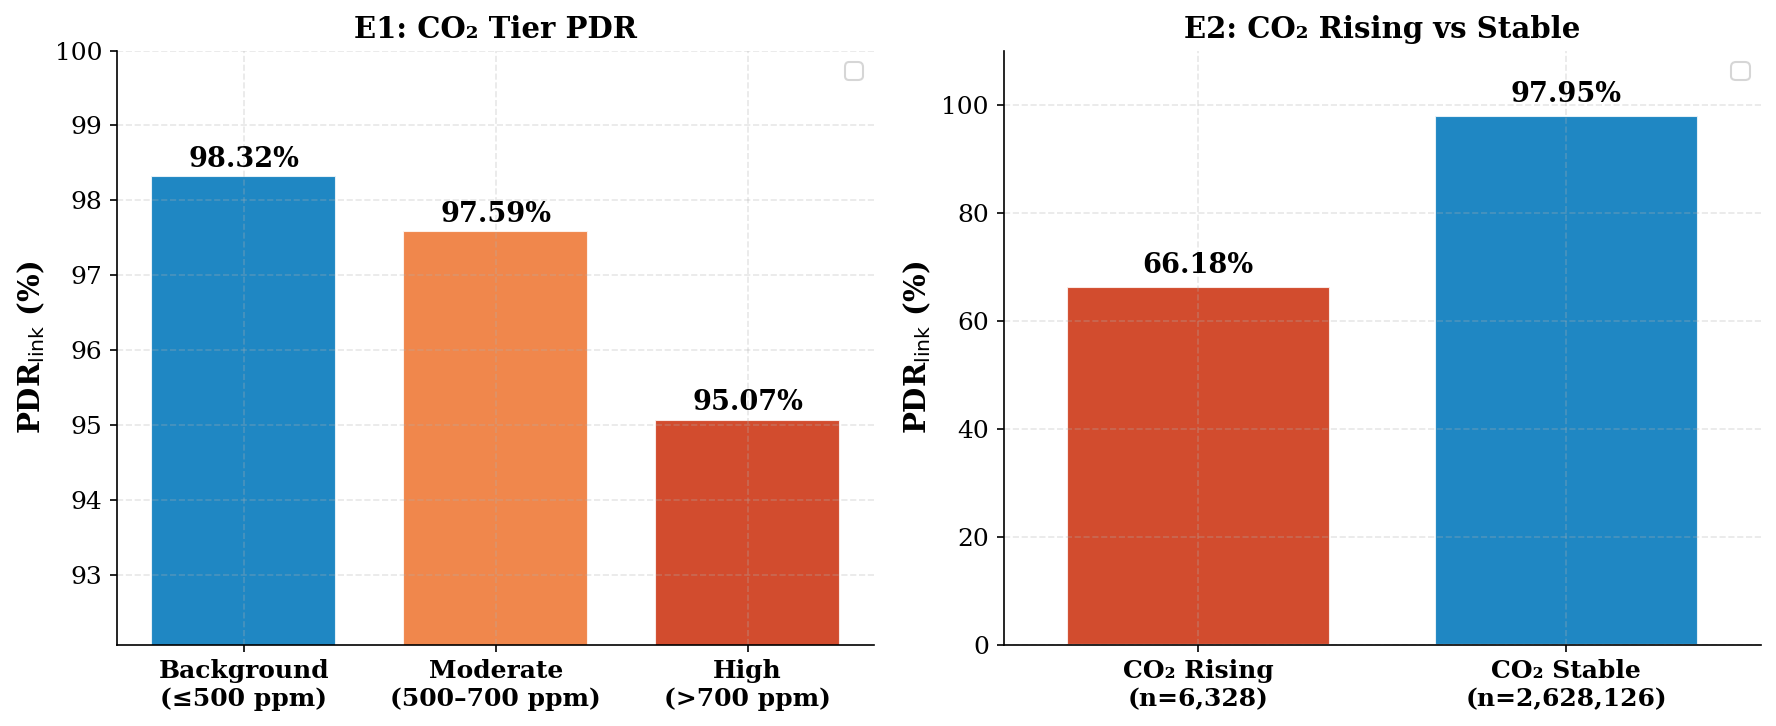

In [5]:
# --- Fig 03-A — Occupancy Events: CO2 Tier PDR + CO2 Rising PDR ---
tiers = ['background', 'moderate', 'high']
xlabs_e1 = ['Background\n(\u2264500 ppm)', 'Moderate\n(500\u2013700 ppm)', 'High\n(>700 ppm)']
pdrs_e1 = [pdr_grp(df_link[df_link['e1_co2_tier'] == t]) for t in tiers]

g1 = df_link[df_link['e2_co2_rising'] == 1]
g0 = df_link[df_link['e2_co2_rising'] == 0]
pdr_rising = pdr_grp(g1)
pdr_stable = pdr_grp(g0)
n_rising = len(g1)
n_stable = len(g0)

# campaign_mean = pdr_grp(df_link)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =====================================================================
# E1: CO2 Tier — single-axis PDR bars (consistent with all other events)
# =====================================================================
colors_e1 = [C['blue'], C['orange'], C['red']]
x0 = np.arange(len(xlabs_e1)) * 0.75
bars_e1 = axes[0].bar(x0, pdrs_e1, 0.55,
                      color=colors_e1, alpha=0.88, edgecolor='white')

for bar, v in zip(bars_e1, pdrs_e1):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[0].set_xticks(x0)
axes[0].set_xticklabels(xlabs_e1, fontsize=12, fontweight='bold')
axes[0].margins(x=0.05)
# axes[0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].set_ylabel('PDR$_{\\mathrm{link}}$ (%)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_ylim(min(pdrs_e1) - 3, 100
                 )
axes[0].legend(fontsize=11)
axes[0].set_title('E1: CO\u2082 Tier PDR', fontsize=14, fontweight='bold')

# =====================================================================
# E2: CO2 Rising vs Stable
# =====================================================================
xlabs_e2 = [f'CO\u2082 Rising\n(n={n_rising:,})', f'CO\u2082 Stable\n(n={n_stable:,})']
x1 = np.arange(2) * 0.7
axes[1].bar(x1, [pdr_rising, pdr_stable], 0.5,
            color=[C['red'], C['blue']], alpha=0.88, edgecolor='white')

for xi, v in zip(x1, [pdr_rising, pdr_stable]):
    axes[1].text(xi, v + 1.5, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[1].set_xticks(x1)
axes[1].set_xticklabels(xlabs_e2, fontsize=12, fontweight='bold')
axes[1].margins(x=0.1)
# axes[1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].set_ylabel('PDR$_{\\mathrm{link}}$ (%)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=11)
axes[1].set_title('E2: CO\u2082 Rising vs Stable', fontsize=14, fontweight='bold')

# Global formatting
# fig.suptitle('Occupancy-Conditioned Reliability (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_a_occupancy_pdr')


## 3 · Temporal Event-Conditioned Reliability  *(§7.3 — RQ2)*

**Hypothesis:** Office hours show lower PDR due to higher human activity  
and increased RF interference from electronic devices. E4 (season) provides  
a complementary year-round view of seasonal variation.

Events: E3 (office hours), E4 (season)


In [6]:
print('=' * 60)
print('TEMPORAL EVENTS (E3–E4)')
print('=' * 60)

temporal_results = {}

# E3: office hours binary
print('\nE3: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e3_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E3_office'] = r

# E4: season
print('\nE4: Season PDR')
for season in ['autumn', 'winter', 'spring', 'summer']:
    g = df_link[df_link['e4_season'] == season]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {season:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE4: Summer vs Winter (key comparison)')
r = pdr_compare(df_link, 'e4_season', 'summer', 'winter')
print_comparison(r, 'Summer vs Winter')
temporal_results['E4_summer_vs_winter'] = r


TEMPORAL EVENTS (E3–E4)

E3: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 97.03%  (n=768,518)
                       0: 98.17%  (n=1,865,936)
    Difference        : -1.13 pp
    95% block CI      : [-1.54, -0.78] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks


E4: Season PDR
    autumn    : 98.29%  (n=703,650)
    winter    : 96.63%  (n=593,470)
    spring    : 97.93%  (n=688,513)
    summer    : 98.35%  (n=648,821)

E4: Summer vs Winter (key comparison)
  Summer vs Winter
                  summer: 98.35%  (n=648,821)
                  winter: 96.63%  (n=593,470)
    Difference        : +1.72 pp
    95% block CI      : [+0.60, +2.89] pp
    Inference         : higher PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks



  Saved: figures/3/03_b_temporal_pdr


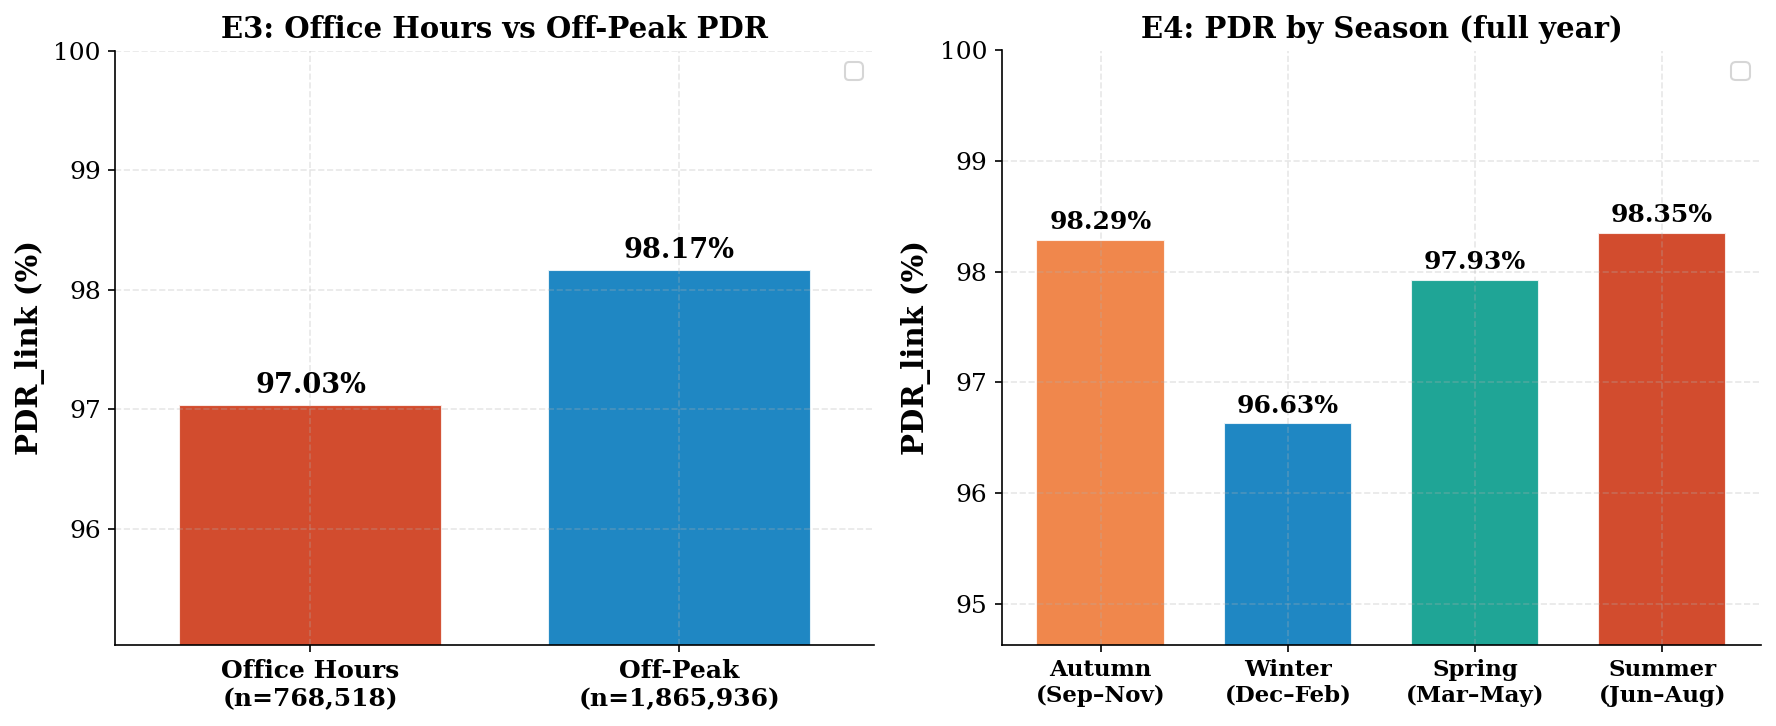

In [7]:
# Fig 03-B — Temporal Events PDR (E3–E4)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# campaign_mean = pdr_grp(df_link)

# =====================================================================
# E3: Office Hours vs Off-Peak PDR
# =====================================================================
oh_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 1])
op_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 0])
oh_n = (df_link['e3_office_hours'] == 1).sum()
op_n = (df_link['e3_office_hours'] == 0).sum()

x0 = np.arange(2) * 0.7
axes[0].bar(x0, [oh_pdr, op_pdr], 0.5,
            color=[C['red'], C['blue']], alpha=0.88, edgecolor='white')

# FIX: Changed axes[1] to axes[0] so the labels match the bars
for xi, v in zip(x0, [oh_pdr, op_pdr]):
    axes[0].text(xi, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[0].set_xticks(x0)
axes[0].set_xticklabels([f'Office Hours\n(n={oh_n:,})', f'Off-Peak\n(n={op_n:,})'],
                        fontsize=12, fontweight='bold')
axes[0].margins(x=0.1)
# axes[0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)

# FIX: Dynamic Y-limit to prevent cutting off the text labels
axes[0].set_ylim(min(oh_pdr, op_pdr) - 2, 100)
axes[0].legend(fontsize=11)
axes[0].set_title('E3: Office Hours vs Off-Peak PDR', fontsize=14, fontweight='bold')

# =====================================================================
# E4: PDR by Season (full year)
# =====================================================================
seasons = ['autumn', 'winter', 'spring', 'summer']
slabs = ['Autumn\n(Sep–Nov)', 'Winter\n(Dec–Feb)', 'Spring\n(Mar–May)', 'Summer\n(Jun–Aug)']
spdrs = [pdr_grp(df_link[df_link['e4_season'] == s]) for s in seasons]

x1 = np.arange(len(slabs)) * 0.8
bars = axes[1].bar(x1, spdrs, 0.55,
                   color=[C['orange'], C['blue'], C['green'], C['red']],
                   alpha=0.88, edgecolor='white')

for bar, v in zip(bars, spdrs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_xticks(x1)
axes[1].set_xticklabels(slabs, fontsize=11, fontweight='bold')
axes[1].margins(x=0.05)
# axes[1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)

# FIX: Changed axes[2] to axes[1] so the limits and title land on the correct plot
axes[1].set_ylim(min(spdrs) - 2, 100)
axes[1].legend(fontsize=11)
axes[1].set_title('E4: PDR by Season (full year)', fontsize=14, fontweight='bold')

# Global formatting
# fig.suptitle('Temporal Events (E3–E4)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_b_temporal_pdr')

## 4 · Air Quality Events — PM2.5  *(§7.5.1 — RQ2)*

PM2.5 spikes mark activity bursts — cleaning, printing, cooking.  
Device-specific 90th percentile thresholds (E5) account for location differences.

Events: E5 (PM2.5 tier), E6 (PM2.5 spike)


In [8]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

air_quality_results = {}

# E5: PM2.5 tier
print('\nE5: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e5_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

# E6: PM2.5 spike -- per device (device-specific 90th percentile threshold)
print('\nE6: PM2.5 Spike (device-specific 90th percentile) — per device')
e6_per_device = []
for dev in sorted(df_link['device_id'].unique()):
    g_dev = df_link[df_link['device_id'] == dev]
    g_spike = g_dev[g_dev['e6_pm25_spike'] == 1]
    g_norm = g_dev[g_dev['e6_pm25_spike'] == 0]

    pdr_spike = pdr_grp(g_spike)
    pdr_norm = pdr_grp(g_norm)
    delta = pdr_spike - pdr_norm

    e6_per_device.append({
        'device_id': dev,
        'n_spike': len(g_spike), 'n_normal': len(g_norm),
        'pdr_spike': pdr_spike, 'pdr_normal': pdr_norm,
        'delta_pp': delta,
    })
    print(f'    {dev}: spike {pdr_spike:6.2f}% (n={len(g_spike):,})  '
          f'vs normal {pdr_norm:6.2f}% (n={len(g_norm):,})  '
          f'-> Delta = {delta:+.2f} pp')

air_quality_results['E6_spike_by_device'] = pd.DataFrame(e6_per_device)

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E5: PM2.5 Absolute Tier
    clean     : 97.99%  (n=2,599,533)
    moderate  : 87.81%  (n=34,490)
    elevated  : 76.42%  (n=431)

E6: PM2.5 Spike (device-specific 90th percentile) — per device
    ED0: spike  94.24% (n=43,879)  vs normal  98.30% (n=396,207)  -> Delta = -4.06 pp
    ED1: spike  94.19% (n=43,404)  vs normal  97.71% (n=391,066)  -> Delta = -3.51 pp
    ED2: spike  94.92% (n=44,017)  vs normal  98.49% (n=396,823)  -> Delta = -3.57 pp
    ED3: spike  94.28% (n=43,321)  vs normal  97.40% (n=390,178)  -> Delta = -3.11 pp
    ED4: spike  95.05% (n=42,613)  vs normal  97.95% (n=392,723)  -> Delta = -2.90 pp
    ED5: spike  96.56% (n=44,929)  vs normal  99.15% (n=405,294)  -> Delta = -2.59 pp


  Saved: figures/3/03_c_air_quality_pdr


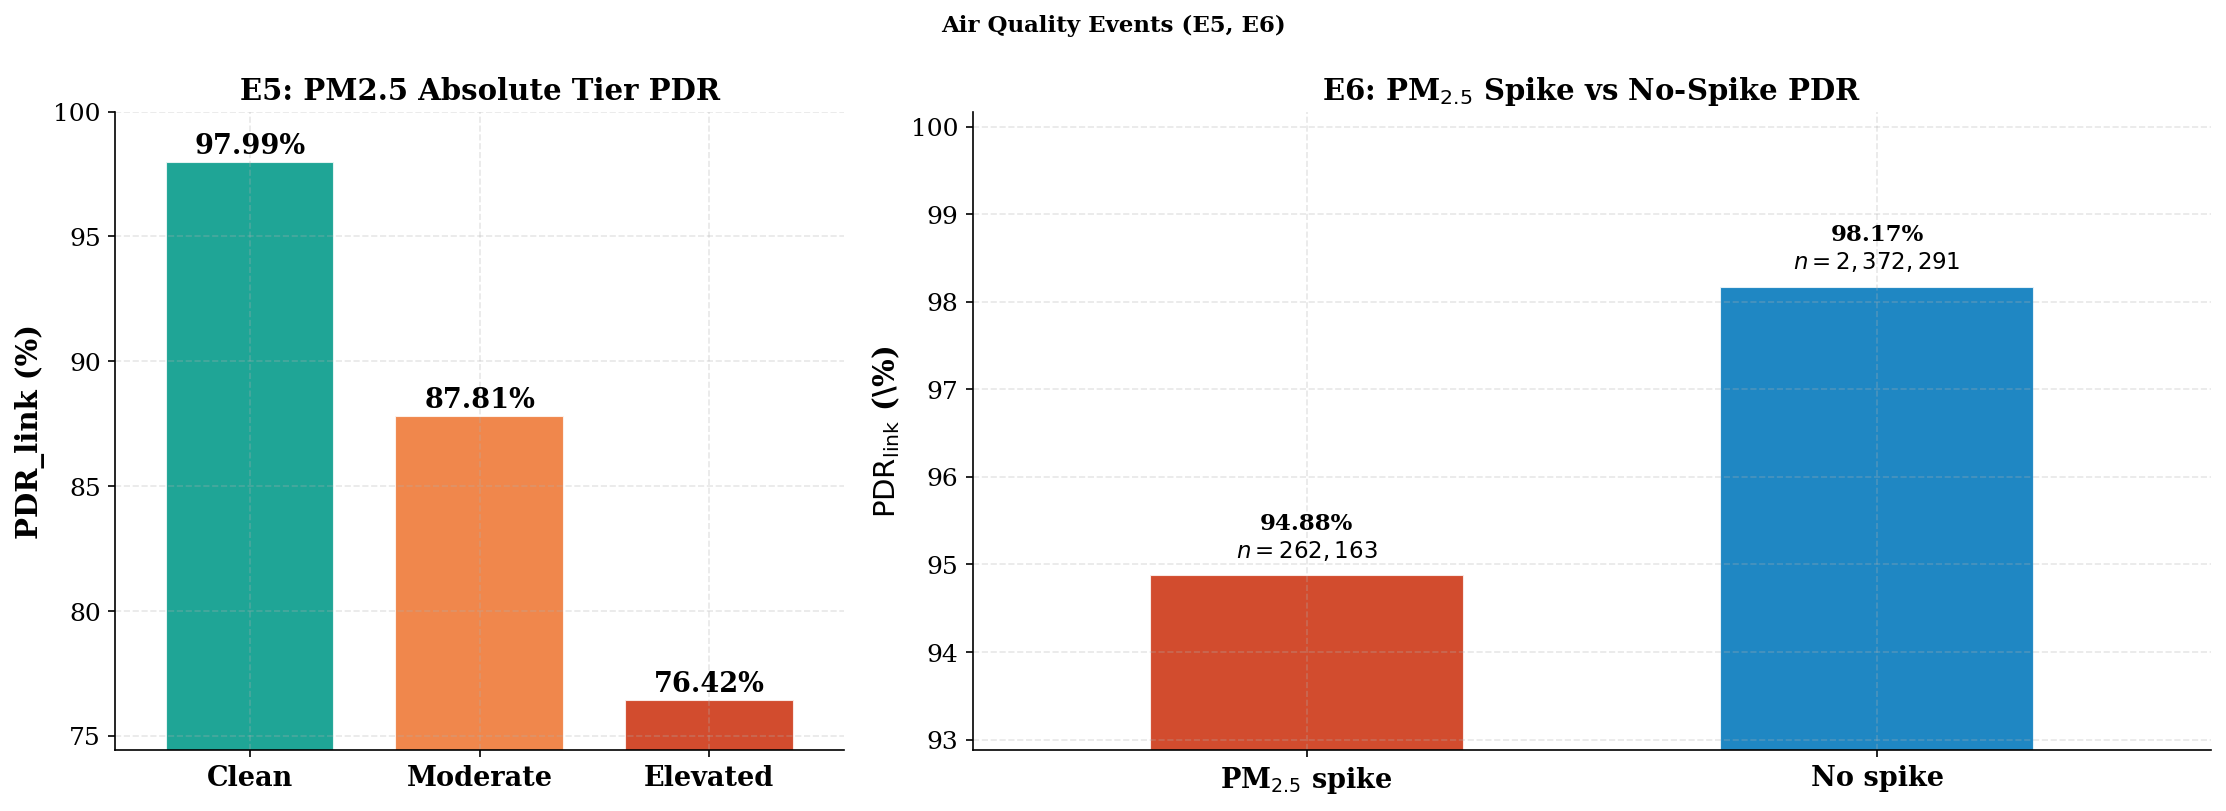

In [9]:
# Fig 03-C — Air Quality Events (E5, E6)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1, 1.7]})

# axes[0] = E5: PM2.5 absolute tier
pm_tiers = ['clean', 'moderate', 'elevated']
pm_labs = ['Clean', 'Moderate', 'Elevated']
pm_pdrs = [pdr_grp(df_link[df_link['e5_pm25_tier'] == t])
           if len(df_link[df_link['e5_pm25_tier'] == t]) > 0 else 0 for t in pm_tiers]

x0 = np.arange(len(pm_labs)) * 0.75
axes[0].bar(x0, pm_pdrs, 0.55,
            color=[C['green'], C['orange'], C['red']], alpha=0.88, edgecolor='white')
for xi, v in zip(x0, pm_pdrs):
    if v > 0:
        axes[0].text(xi, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(pm_labs, fontsize=13, fontweight='bold')
axes[0].margins(x=0.08)
axes[0].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=12)
valid_pdrs = [v for v in pm_pdrs if v > 0]
axes[0].set_ylim(min(valid_pdrs) - 2 if valid_pdrs else 0, 100)
axes[0].set_title('E5: PM2.5 Absolute Tier PDR', fontsize=14, fontweight='bold')

# # axes[1] = E6: PM2.5 spike, per device
# devices_e6 = sorted(df_link['device_id'].unique())
# spike_vals, normal_vals = [], []
# for dev in devices_e6:
#     g_dev = df_link[df_link['device_id'] == dev]
#     spike_vals.append(pdr_grp(g_dev[g_dev['e6_pm25_spike'] == 1]))
#     normal_vals.append(pdr_grp(g_dev[g_dev['e6_pm25_spike'] == 0]))
#
# x1 = np.arange(len(devices_e6)) * 0.85
# w1 = 0.32
#
# b1 = axes[1].bar(x1 - w1 / 2, spike_vals, w1, color=C['red'], alpha=0.88,
#                   edgecolor='white', label='Spike')
# b2 = axes[1].bar(x1 + w1 / 2, normal_vals, w1, color=C['blue'], alpha=0.88,
#                   edgecolor='white', label='No spike')
#
# for bar, v in zip(b1, spike_vals):
#     axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.15, f'{v:.1f}%',
#                  ha='center', va='bottom', fontsize=10, fontweight='bold')
# for bar, v in zip(b2, normal_vals):
#     axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.15, f'{v:.1f}%',
#                  ha='center', va='bottom', fontsize=10, fontweight='bold')
#
# axes[1].set_xticks(x1)
# axes[1].set_xticklabels(devices_e6, fontsize=13, fontweight='bold')
# axes[1].margins(x=0.04)
# axes[1].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
# axes[1].tick_params(axis='y', labelsize=12)
# all_e6_vals = spike_vals + normal_vals
# axes[1].set_ylim(min(all_e6_vals) - 2, max(all_e6_vals) + 2)
# axes[1].legend(fontsize=12, loc='upper right')
# axes[1].set_title('E6: PM2.5 Spike vs No-Spike PDR, per Device', fontsize=14, fontweight='bold')


# axes[1] = E6: PM2.5 spike vs no spike, pooled across all devices

g_spike = df_link[df_link['e6_pm25_spike'] == 1]
g_normal = df_link[df_link['e6_pm25_spike'] == 0]

spike_pdr = pdr_grp(g_spike)
normal_pdr = pdr_grp(g_normal)

labels = ['PM$_{2.5}$ spike', 'No spike']
values = [spike_pdr, normal_pdr]
counts = [len(g_spike), len(g_normal)]

x1 = np.arange(len(labels))

bars = axes[1].bar(
    x1,
    values,
    width=0.55,
    color=[C['red'], C['blue']],
    alpha=0.88,
    edgecolor='white'
)

for bar, value, n in zip(bars, values, counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.15,
        f'{value:.2f}%\n$n={n:,}$',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_xticks(x1)
axes[1].set_xticklabels(
    labels,
    fontsize=13,
    fontweight='bold'
)

axes[1].set_ylabel(
    r'$\mathrm{PDR_{link}}$ (\%)',
    fontsize=14,
    fontweight='bold'
)

axes[1].tick_params(axis='y', labelsize=12)

axes[1].set_ylim(
    min(values) - 2,
    max(values) + 2
)

axes[1].set_title(
    r'E6: PM$_{2.5}$ Spike vs No-Spike PDR',
    fontsize=14,
    fontweight='bold'
)

axes[1].margins(x=0.20)

fig.suptitle('Air Quality Events (E5, E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_c_air_quality_pdr')

## 5 · Atmospheric Events  *(§7.5.2 — RQ2)*

Events: E7 (temperature tier), E8 (humidity tier)


In [10]:
print('=' * 60)
print('ATMOSPHERIC EVENTS (E7–E8)')
print('=' * 60)

atm_results = {}

# E7: temperature tier
print('\nE7: Temperature Tier PDR')
for tier in ['cool', 'moderate', 'warm']:
    g = df_link[df_link['e7_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE7: Warm vs Cool (key comparison)')
r = pdr_compare(df_link, 'e7_temp_tier', 'warm', 'cool')
print_comparison(r, 'Warm vs Cool')
atm_results['E7_warm_vs_cool'] = r

# E8: humidity tier
print('\nE8: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid']:
    g = df_link[df_link['e8_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE8: Humid vs Dry (key comparison)')
r = pdr_compare(df_link, 'e8_humidity_tier', 'humid', 'dry')
print_comparison(r, 'Humid vs Dry')
atm_results['E8_humid_vs_dry'] = r


ATMOSPHERIC EVENTS (E7–E8)

E7: Temperature Tier PDR
    cool      : 97.30%  (n=876,801)
    moderate  : 97.99%  (n=886,499)
    warm      : 98.21%  (n=871,154)

E7: Warm vs Cool (key comparison)
  Warm vs Cool
                    warm: 98.21%  (n=871,154)
                    cool: 97.30%  (n=876,801)
    Difference        : +0.91 pp
    95% block CI      : [+0.17, +1.63] pp
    Inference         : higher PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks


E8: Humidity Tier PDR
    dry       : 96.90%  (n=387,642)
    normal    : 98.00%  (n=2,246,079)
    humid     : 94.70%  (n=733)

E8: Humid vs Dry (key comparison)
  Humid vs Dry
                   humid: 94.70%  (n=733)
                     dry: 96.90%  (n=387,642)
    Difference        : -2.20 pp
    95% block CI      : [-3.00, +3.82] pp
    Inference         : inconclusive  ✗ inconclusive (CI includes 0)
    Bootstrap design  : 8,741 resamples of 52 x 7-day blocks



  Saved: figures/3/03_d_atmospheric_pdr


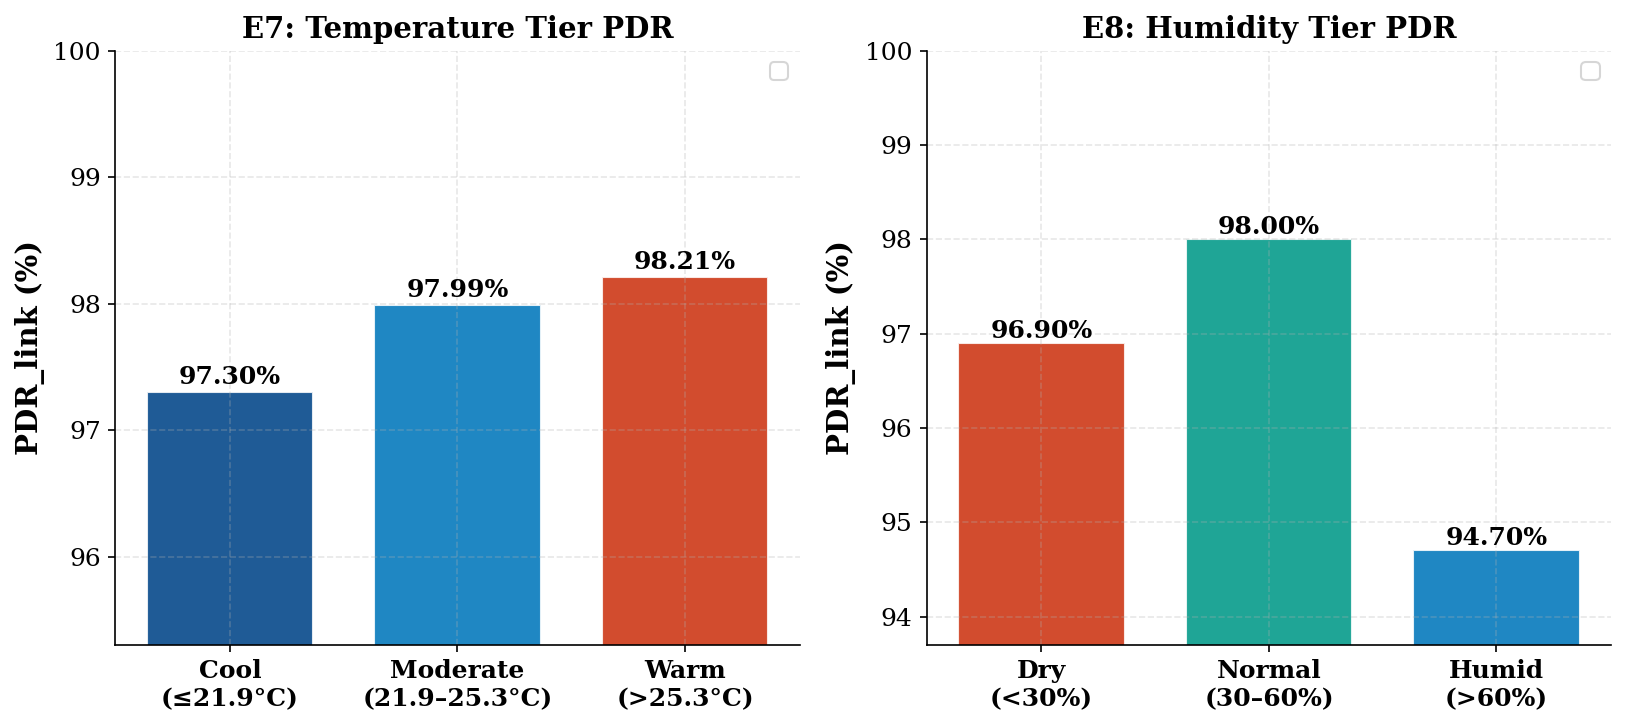

In [11]:
# Fig 03-D — Atmospheric Events PDR (E7–E8)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)
# campaign_mean = pdr_grp(df_link)

# E7: temperature — 3 absolute tiers (cool ≤ 21.9°C, moderate 21.9–25.3°C, warm > 25.3°C)
tt = ['cool', 'moderate', 'warm']
tt_labs = ['Cool\n(≤21.9°C)', 'Moderate\n(21.9–25.3°C)', 'Warm\n(>25.3°C)']
tt_pdrs = [pdr_grp(df_link[df_link['e7_temp_tier'] == t]) for t in tt]
x0 = np.arange(len(tt_labs)) * 0.75
bars = axes[0, 0].bar(x0, tt_pdrs, 0.55,
                      color=[C['navy'], C['blue'], C['red']],
                      alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pdrs):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}%',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x0)
axes[0, 0].set_xticklabels(tt_labs, fontsize=12, fontweight='bold')
axes[0, 0].margins(x=0.05)
# axes[0, 0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 0].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='y', labelsize=12)
axes[0, 0].set_ylim(min(tt_pdrs) - 2, 100)
axes[0, 0].legend(fontsize=11)
axes[0, 0].set_title('E7: Temperature Tier PDR', fontsize=14, fontweight='bold')

# E8: humidity — ASHRAE 55 comfort bands (dry < 30%, normal 30–60%, humid > 60%)
ht = ['dry', 'normal', 'humid']
ht_labs = ['Dry\n(<30%)', 'Normal\n(30–60%)', 'Humid\n(>60%)']
ht_pdrs = [pdr_grp(df_link[df_link['e8_humidity_tier'] == t])
           if len(df_link[df_link['e8_humidity_tier'] == t]) > 0 else 0 for t in ht]
x1 = np.arange(len(ht_labs)) * 0.75
bars = axes[0, 1].bar(x1, ht_pdrs, 0.55,
                      color=[C['red'], C['green'], C['blue']],
                      alpha=0.88, edgecolor='white')
for bar, v in zip(bars, ht_pdrs):
    if v > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v, f'{v:.2f}%',
                        ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x1)
axes[0, 1].set_xticklabels(ht_labs, fontsize=12, fontweight='bold')
axes[0, 1].margins(x=0.05)
# axes[0, 1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 1].set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='y', labelsize=12)
valid_pdrs = [v for v in ht_pdrs if v > 0]
axes[0, 1].set_ylim((min(valid_pdrs) - 1 if valid_pdrs else 0), 100)
axes[0, 1].legend(fontsize=11)
axes[0, 1].set_title('E8: Humidity Tier PDR', fontsize=14, fontweight='bold')

# fig.suptitle('Atmospheric Events (E7–E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_d_atmospheric_pdr')


## 6 · Spreading Factor and SF×Occupancy Interaction  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.

**Novel joint analysis:** SF × CO₂ interaction — during high-occupancy periods
the PDR gap between low-SF and high-SF transmissions should widen, since longer
airtime at high SF increases the probability of overlapping with concurrent
transmissions from other devices and networks.

Event: E9 (spreading factor), combined with E1 (CO₂ tier)


In [12]:
print('=' * 60)
print('SPREADING FACTOR EVENT (E9)')
print('=' * 60)

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
sf_pdrs = {}
sf_results = {}

print('\nE9: PDR by Spreading Factor')
for sf in [7, 8, 9, 10, 11, 12]:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')

print('\nE9: SF12 vs SF7 (key comparison)')
r = pdr_compare(df_link, 'e9_sf', 12, 7)
print_comparison(r, 'SF12 vs SF7')
sf_results['E9_sf12_vs_sf7'] = r


SPREADING FACTOR EVENT (E9)

E9: PDR by Spreading Factor
    SF 7 (ToA=   71.9ms): 98.65%  (n=536,935)
    SF 8 (ToA=  133.6ms): 98.45%  (n=534,465)
    SF 9 (ToA=  246.8ms): 97.76%  (n=518,646)
    SF10 (ToA=  452.6ms): 97.68%  (n=500,752)
    SF11 (ToA=  987.1ms): 96.38%  (n=269,154)
    SF12 (ToA= 1810.4ms): 96.91%  (n=274,502)

    PDR drop SF7→SF12: 1.74 pp

E9: SF12 vs SF7 (key comparison)
  SF12 vs SF7
                      12: 96.91%  (n=274,502)
                       7: 98.65%  (n=536,935)
    Difference        : -1.74 pp
    95% block CI      : [-2.26, -1.28] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks



  Saved: figures/3/03_e_sf_pdr


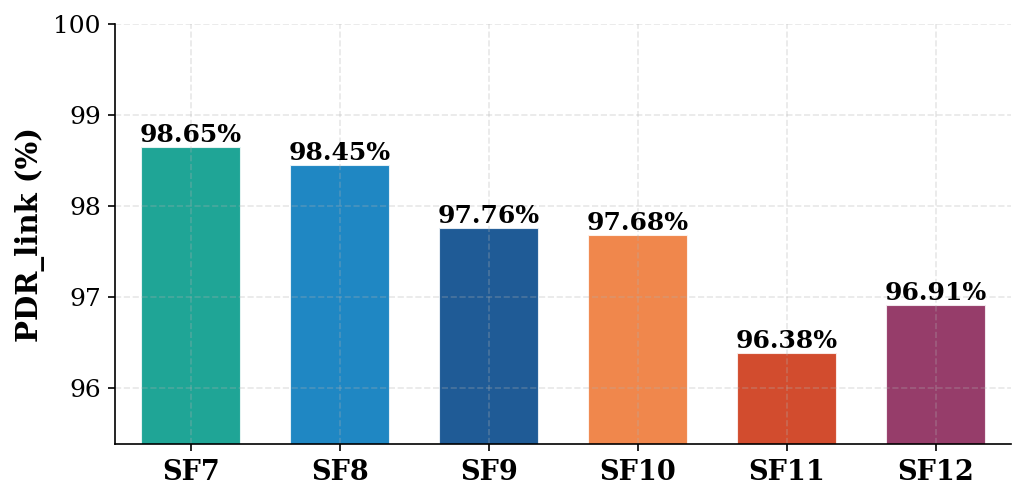

In [13]:
# Fig 03-E — PDR by Spreading Factor (E9)
fig, ax = plt.subplots(figsize=(7, 3.5))

sfs = [7, 8, 9, 10, 11, 12]
sf_pdr_vals = []
sf_labs = []

for sf in sfs:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = (rx / (rx + lost) * 100) if (rx + lost) > 0 else 0
    sf_pdr_vals.append(pdr)
    sf_labs.append(f'SF{sf}')

bar_colors = [C['green'], C['blue'], C['navy'], C['orange'], C['red'], C['brown']]

x = np.arange(len(sf_labs)) * 0.82
w = 0.55
ax.bar(x, sf_pdr_vals, w, color=bar_colors, alpha=0.88, edgecolor='white')

for xi, v in zip(x, sf_pdr_vals):
    if v > 0:
        ax.text(xi, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(sf_labs, fontsize=13, fontweight='bold')
ax.margins(x=0.03)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(sf_pdr_vals) - 1 if sf_pdr_vals else 0, 100)
# ax.set_title(f'E9: PDR by Spreading Factor\n(PDR drop SF7→SF12: {sf_pdr_vals[0] - sf_pdr_vals[-1]:.2f} pp)',
#               fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_e_sf_pdr')


## 7 · Signal Context Event  *(§7.5 — RQ2)*

**Hypothesis:** Weaker signal → higher loss rate.

E10 (ESP, effective signal power) uses the ThingPark six-tier classification
of the last received packet as a proxy for channel state. A flat PDR across
ESP tiers would indicate that signal quality is not the dominant loss driver,
supporting the collision-dominated hypothesis.

Event: E10 (ESP tier)


In [14]:
print('=' * 60)
print('SIGNAL CONTEXT EVENT (E10)')
print('=' * 60)

signal_results = {}

# E10: ESP tier — 3 analytical tiers
print('E10: PDR by ESP Tier (poor / moderate / strong)')
for tier in ['poor', 'moderate', 'strong']:
    g = df_link[df_link['e10_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e10_esp_tier', 'poor', 'strong')
print()
print_comparison(r, 'Poor ESP vs Strong ESP')
signal_results['E10_poor_vs_strong'] = r

SIGNAL CONTEXT EVENT (E10)
E10: PDR by ESP Tier (poor / moderate / strong)
    poor        : 96.75%  (n=230,075)
    moderate    : 97.43%  (n=116,196)
    strong      : 97.96%  (n=2,288,183)

  Poor ESP vs Strong ESP
                    poor: 96.75%  (n=230,075)
                  strong: 97.96%  (n=2,288,183)
    Difference        : -1.21 pp
    95% block CI      : [-1.56, -0.91] pp
    Inference         : lower PDR  ✓ statistically supported
    Bootstrap design  : 10,000 resamples of 52 x 7-day blocks



  Saved: figures/3/03_g_signal_context_pdr


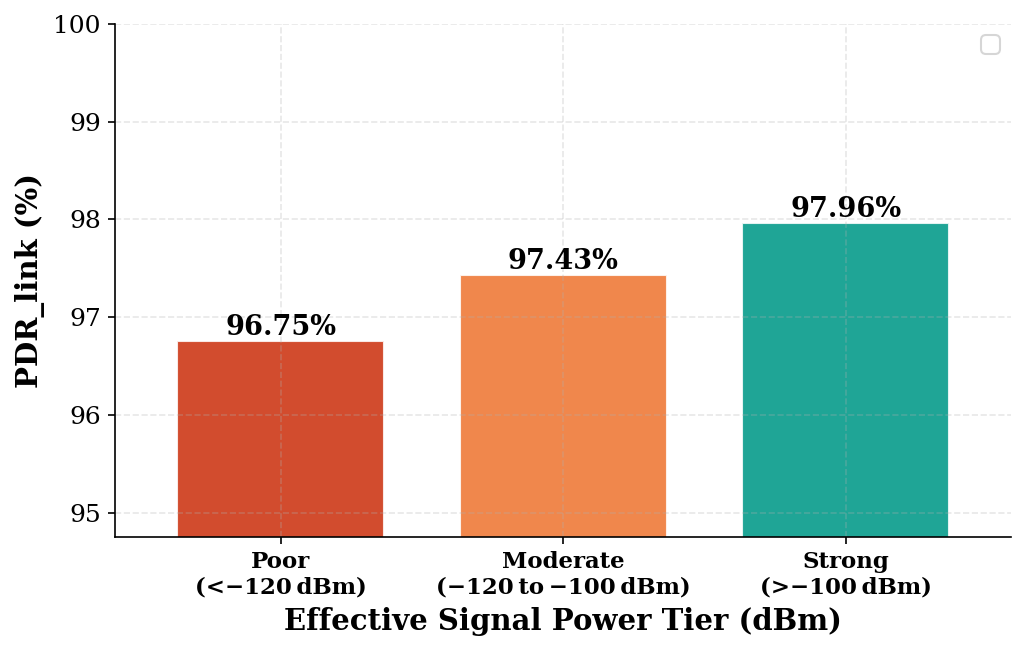

In [15]:
# Fig 03-G — Signal Context PDR (E10) — 3 analytical tiers
fig, ax = plt.subplots(figsize=(7, 4.5))

et = ['poor', 'moderate', 'strong']
et_labs = ['Poor\n(<−120\u202fdBm)', 'Moderate\n(−120\u202fto\u202f−100\u202fdBm)', 'Strong\n(>−100\u202fdBm)']
et_pdrs = [pdr_grp(df_link[df_link['e10_esp_tier'] == t])
           if len(df_link[df_link['e10_esp_tier'] == t]) > 0 else 0
           for t in et]
et_colors = [C['red'], C['orange'], C['green']]

x = np.arange(len(et_labs)) * 0.75
bars = ax.bar(x, et_pdrs, 0.55, color=et_colors, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, et_pdrs):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(et_labs, fontsize=11, fontweight='bold')
ax.margins(x=0.08)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Effective Signal Power Tier (dBm)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
valid_pdrs = [v for v in et_pdrs if v > 0]
ax.set_ylim((min(valid_pdrs) - 2 if valid_pdrs else 0), 100)
# ax.axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
ax.legend(fontsize=11)
# ax.set_title('E10: ESP Tier PDR (poor / moderate / strong)', fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_g_signal_context_pdr')

## 8 · Complete Event Summary Table  *(Tables 7.x)*

All 10 events with observed ΔPDR and its 95% block-bootstrap confidence interval — maps directly to thesis Chapter 7 tables.


In [16]:
print('=' * 60)
print('ALL EVENTS \u2014 PDR SUMMARY (E1\u2013E10, block-bootstrap 95% CI)')
print('=' * 60)

all_results = []

binary_events = [
    ('E2', 'e2_co2_rising', 1, 0, 'CO2 rising vs stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E6', 'e6_pm25_spike', 1, 0, 'PM2.5 spike vs normal'),
]
cat_events = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E4', 'e4_season', 'summer', 'winter', 'Summer vs Winter'),
    ('E5', 'e5_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E7', 'e7_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E8', 'e8_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E9', 'e9_sf', 12, 7, 'SF12 vs SF7'),
    ('E10', 'e10_esp_tier', 'poor', 'strong', 'Poor vs Strong ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append({
        'Event': eid, 'Comparison': label,
        'PDR_active': r['pdr1'], 'PDR_inactive': r['pdr0'],
        'Diff_pp': r['diff_pp'],
        'CI_low_pp': r['ci_low_pp'], 'CI_high_pp': r['ci_high_pp'],
        'Supported': r['statistically_supported'],
    })

results_df = pd.DataFrame(all_results).sort_values('Diff_pp')
plot_df = results_df.copy()

print(f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} "
      f"{'Diff(pp)':>10} {'95% CI (pp)':>20} {'Supported':>10}")
print('-' * 112)
for _, row in results_df.iterrows():
    ci = f"[{row['CI_low_pp']:+.2f}, {row['CI_high_pp']:+.2f}]"
    sup = '\u2713' if row['Supported'] else '\u2717'
    print(f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
          f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
          f"{ci:>20} {sup:>10}")


ALL EVENTS — PDR SUMMARY (E1–E10, block-bootstrap 95% CI)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)          95% CI (pp)  Supported
----------------------------------------------------------------------------------------------------------------
E2     CO2 rising vs stable                     66.18%        97.95%    -31.77     [-36.22, -27.00]          ✓
E5     Elevated vs Clean PM2.5                  76.42%        97.99%    -21.57     [-36.52, -15.45]          ✓
E6     PM2.5 spike vs normal                    94.88%        98.17%     -3.29       [-4.36, -2.19]          ✓
E1     High CO2 vs Background                   95.07%        98.32%     -3.25       [-4.14, -2.36]          ✓
E8     Humid vs Dry                             94.70%        96.90%     -2.20       [-3.00, +3.82]          ✗
E9     SF12 vs SF7                              96.91%        98.65%     -1.74       [-2.26, -1.28]          ✓
E10    Poor vs Strong ESP                       96.

  Saved: figures/3/03_h1_pdr_difference_per_event


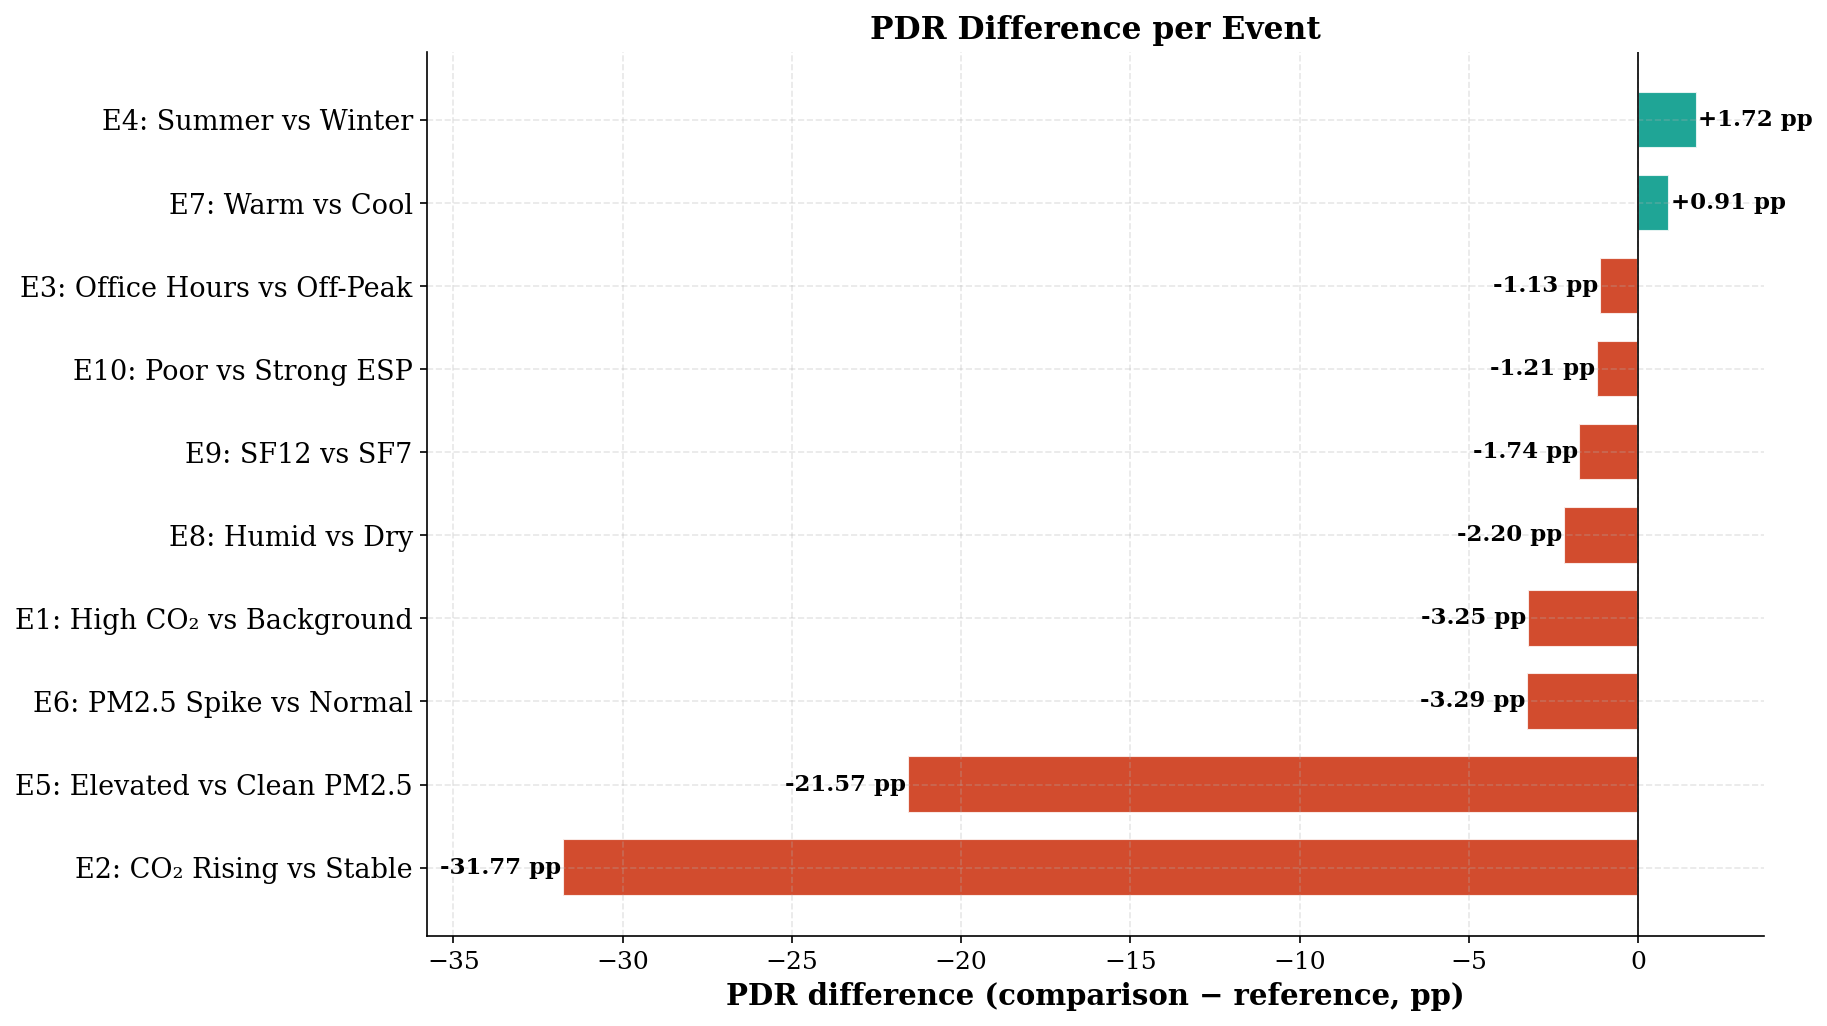

  Saved: figures/3/03_h2_event_block_bootstrap_confidence_intervals


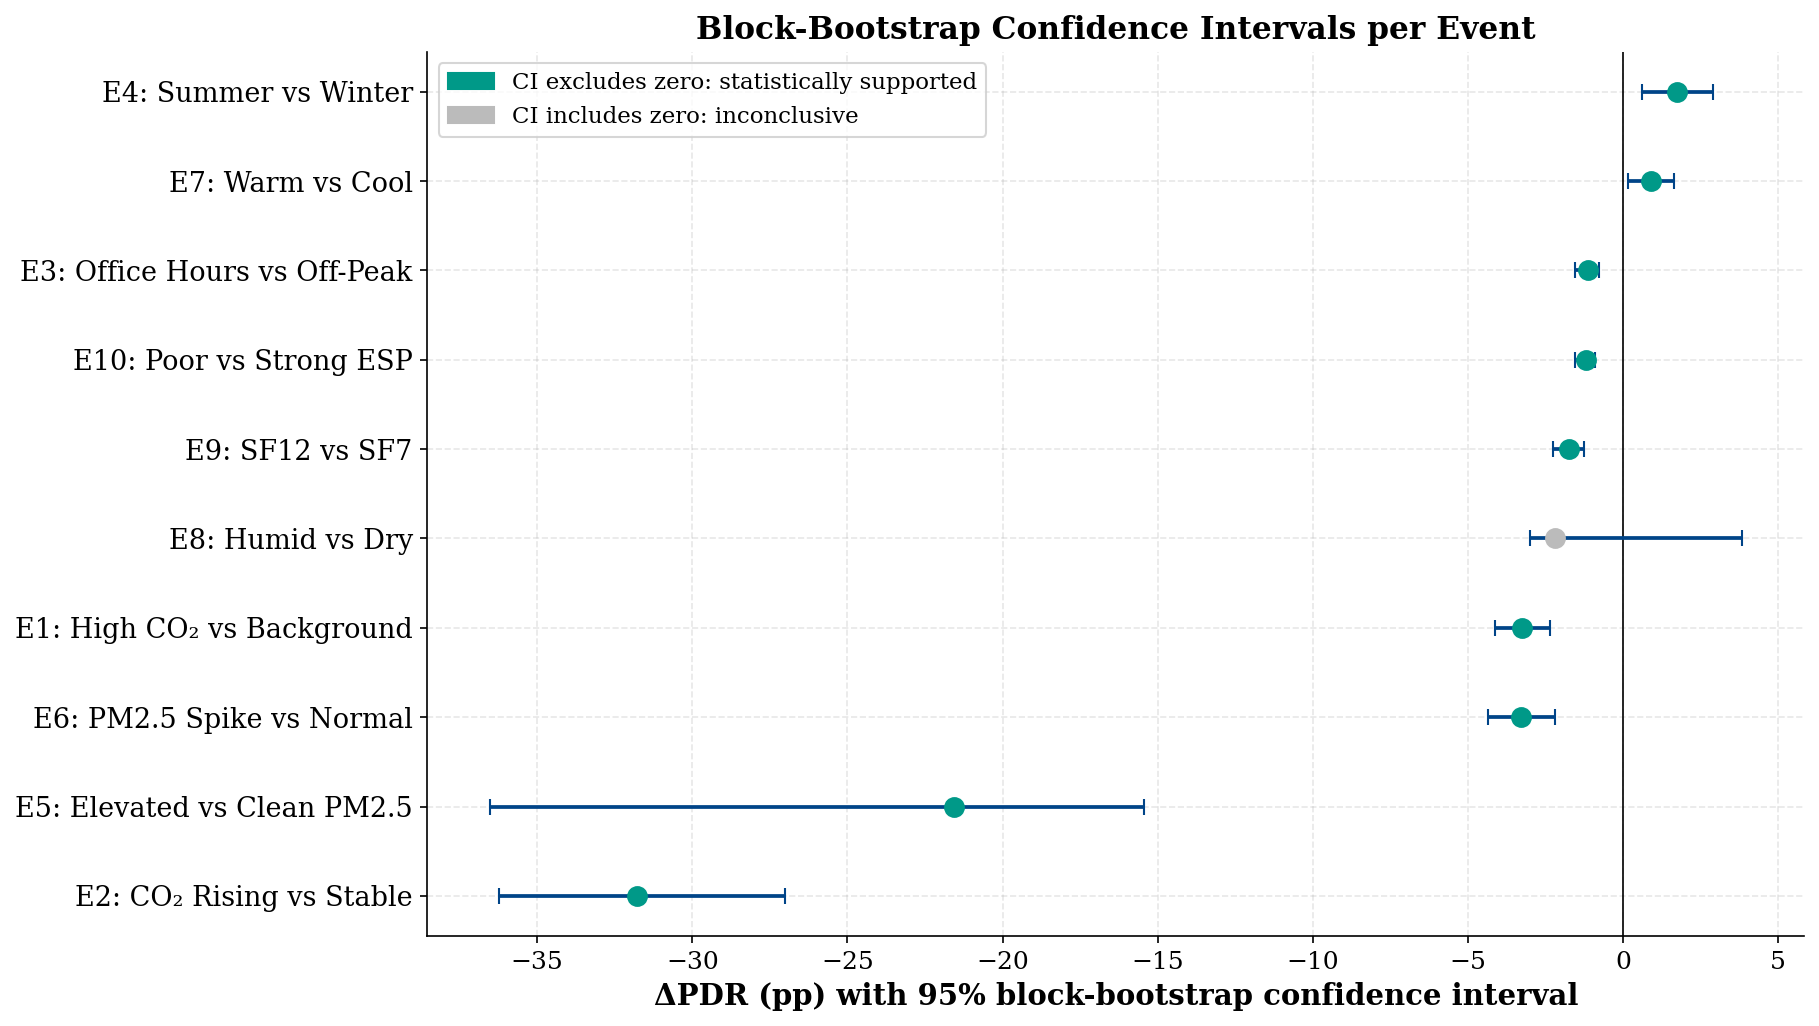

In [17]:
# Fig 03-H1 -- PDR Difference per Event

plot_df = plot_df.sort_values('Diff_pp').reset_index(drop=True)

event_labels = {
    'E1': 'E1: High CO\u2082 vs Background',
    'E2': 'E2: CO\u2082 Rising vs Stable',
    'E3': 'E3: Office Hours vs Off-Peak',
    'E4': 'E4: Summer vs Winter',
    'E5': 'E5: Elevated vs Clean PM2.5',
    'E6': 'E6: PM2.5 Spike vs Normal',
    'E7': 'E7: Warm vs Cool',
    'E8': 'E8: Humid vs Dry',
    'E9': 'E9: SF12 vs SF7',
    'E10': 'E10: Poor vs Strong ESP',
}

plot_df['label'] = plot_df['Event'].map(event_labels)

fig1, ax1 = plt.subplots(figsize=(13, 7))

colors = [
    C['red'] if value < 0 else C['green']
    for value in plot_df['Diff_pp']
]

bars = ax1.barh(
    plot_df['label'],
    plot_df['Diff_pp'],
    color=colors,
    alpha=0.88,
    edgecolor='white',
    height=0.68
)

ax1.axvline(
    x=0,
    color='black',
    linewidth=0.8,
    linestyle='-'
)

for bar, value in zip(bars, plot_df['Diff_pp']):
    ax1.text(
        value + (0.05 if value >= 0 else -0.05),
        bar.get_y() + bar.get_height() / 2,
        f'{value:+.2f} pp',
        ha='left' if value >= 0 else 'right',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

ax1.tick_params(axis='y', labelsize=13)

ax1.set_xlim(
    plot_df['Diff_pp'].min() - 4,
    plot_df['Diff_pp'].max() + 2
)

ax1.set_xlabel(
    'PDR difference (comparison \u2212 reference, pp)',
    fontsize=14,
    fontweight='bold'
)

ax1.set_title(
    'PDR Difference per Event',
    fontsize=15,
    fontweight='bold'
)

fig1.tight_layout()
fig1.subplots_adjust(left=0.28)

save_fig(
    fig1,
    '03_h1_pdr_difference_per_event'
)

plt.show()

# Fig 03-H2 -- Block-Bootstrap Confidence Intervals per Event

fig2, ax2 = plt.subplots(figsize=(13, 7))

y_pos = np.arange(len(plot_df))

err_low = (
        plot_df['Diff_pp'] - plot_df['CI_low_pp']
).clip(lower=0)

err_high = (
        plot_df['CI_high_pp'] - plot_df['Diff_pp']
).clip(lower=0)

point_colors = [
    C['green'] if supported else C['grey']
    for supported in plot_df['Supported']
]

ax2.errorbar(
    plot_df['Diff_pp'],
    y_pos,
    xerr=[err_low, err_high],
    fmt='none',
    capsize=4,
    elinewidth=1.8,
    ecolor=C['navy'],
    zorder=3
)

for y_value, delta, point_color in zip(
        y_pos,
        plot_df['Diff_pp'],
        point_colors
):
    ax2.plot(
        delta,
        y_value,
        marker='o',
        markersize=9,
        color=point_color,
        linestyle='none',
        zorder=5
    )

ax2.axvline(
    x=0,
    color='black',
    linewidth=0.8,
    linestyle='-'
)

ax2.set_yticks(y_pos)

ax2.set_yticklabels(
    plot_df['label'],
    fontsize=13
)

ax2.set_xlabel(
    '\u0394PDR (pp) with 95% block-bootstrap confidence interval',
    fontsize=14,
    fontweight='bold'
)

ax2.set_title(
    'Block-Bootstrap Confidence Intervals per Event',
    fontsize=15,
    fontweight='bold'
)

legend_elements = [
    mpatches.Patch(
        color=C['green'],
        label='CI excludes zero: statistically supported'
    ),
    mpatches.Patch(
        color=C['grey'],
        label='CI includes zero: inconclusive'
    )
]

ax2.legend(
    handles=legend_elements,
    fontsize=11,
    loc='best'
)

fig2.tight_layout()
fig2.subplots_adjust(left=0.28)

save_fig(
    fig2,
    '03_h2_event_block_bootstrap_confidence_intervals'
)

plt.show()

## 10 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**RQ3:** Which conditions are most strongly associated with loss risk?

Binary outcome: `y = 1[tx_loss > 0]`
Predictors: all 10 events + device-ID fixed effects (ED0 as reference).
**OR > 1** → increased loss probability. 95% CI from bootstrap.

Change `N_BOOT = 10` for testing, `N_BOOT = 100` for final thesis run.


In [18]:
from sklearn.linear_model import LogisticRegression

df_link = df_link.copy()
df_link['time'] = pd.to_datetime(df_link['time'])
df_link['loss_occurred'] = (df_link['tx_loss'] > 0).astype(int)

feature_df = pd.get_dummies(
    df_link[[
        'e1_co2_tier',
        'e2_co2_rising',
        'e3_office_hours',
        'e4_season',
        'e6_pm25_spike',
        'e5_pm25_tier',
        'e7_temp_tier',
        'e8_humidity_tier',
        'e9_sf',
        'e10_esp_tier',
        'device_id',
    ]],
    drop_first=True,
).astype(float)

X = feature_df.to_numpy(dtype=float)
feat_names = feature_df.columns.tolist()
y = df_link['loss_occurred'].to_numpy(dtype=int)

# Use the same one-day block definition as the PDR bootstrap
campaign_start = df_link['time'].min().floor('D')

lr_block_id = (
    (df_link['time'] - campaign_start).dt.total_seconds()
    // (24 * 60 * 60)
).astype(int).to_numpy()

# Use 25–50 while testing and at least 1,000 for the final run
N_BOOT = 25
RANDOM_STATE = 42


def _new_lr():
    return LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        C=1.0,
    )


def fit_lr_block_bootstrap(
    X,
    y,
    groups,
    feat_names,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
):
    if np.unique(y).size != 2:
        raise ValueError(
            'The outcome must contain both classes.'
        )

    # Full-data coefficient estimates
    model = _new_lr()
    model.fit(X, y)

    coefs = model.coef_[0]
    odds_ratios = np.exp(coefs)

    # Map every row to its observed daily block
    _, group_inverse = np.unique(
        groups,
        return_inverse=True,
    )

    n_blocks = group_inverse.max() + 1
    rng = np.random.default_rng(random_state)

    boot_coefs = []

    for b in range(n_boot):
        # Sample complete daily blocks with replacement
        sampled_blocks = rng.integers(
            0,
            n_blocks,
            size=n_blocks,
        )

        block_multiplicity = np.bincount(
            sampled_blocks,
            minlength=n_blocks,
        )

        # Every row from a selected day receives the
        # multiplicity assigned to that day
        row_weights = block_multiplicity[
            group_inverse
        ].astype(float)

        keep = row_weights > 0

        # Skip a replicate only when one outcome class is absent
        if np.unique(y[keep]).size != 2:
            continue

        weights = row_weights[keep]

        # Keep the total sample weight comparable across replicates
        weights *= len(y) / weights.sum()

        boot_model = _new_lr()

        boot_model.fit(
            X[keep],
            y[keep],
            sample_weight=weights,
        )

        boot_coefs.append(
            boot_model.coef_[0]
        )

        if (b + 1) % 100 == 0 or (b + 1) == n_boot:
            print(
                f'  Completed {b + 1:,} of '
                f'{n_boot:,} block resamples'
            )

    boot_coefs = np.asarray(
        boot_coefs,
        dtype=float,
    )

    minimum_valid = int(
        np.ceil(0.9 * n_boot)
    )

    if len(boot_coefs) < minimum_valid:
        raise RuntimeError(
            f'Only {len(boot_coefs):,} of '
            f'{n_boot:,} bootstrap fits were valid. '
            f'At least {minimum_valid:,} were required.'
        )

    ci_lo = np.exp(
        np.percentile(
            boot_coefs,
            2.5,
            axis=0,
        )
    )

    ci_hi = np.exp(
        np.percentile(
            boot_coefs,
            97.5,
            axis=0,
        )
    )

    ci_df = pd.DataFrame(
        {
            'OR': odds_ratios,
            'CI_lo': ci_lo,
            'CI_hi': ci_hi,
        },
        index=feat_names,
    )

    ci_df['Supported'] = (
        (ci_df['CI_lo'] > 1.0)
        | (ci_df['CI_hi'] < 1.0)
    )

    result = ci_df['OR'].sort_values(
        ascending=False
    )

    return result, ci_df


print(
    f'Fitting loss occurrence model with '
    f'{N_BOOT:,} one-day block resamples'
)

print(f'Features {len(feat_names)}')

odds_ratios, ci_loss = fit_lr_block_bootstrap(
    X,
    y,
    lr_block_id,
    feat_names,
)

print(
    f'\n{"Predictor":<40} '
    f'{"OR":>8} '
    f'{"95% CI":>22} '
    f'{"Inference":>24}'
)

print('-' * 98)
print('\nEVENT PREDICTORS')

for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'):
        continue

    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']

    if lo > 1.0:
        inference = 'higher adjusted odds'
    elif hi < 1.0:
        inference = 'lower adjusted odds'
    else:
        inference = 'inconclusive'

    print(
        f'{feat:<40} '
        f'{OR:>8.4f} '
        f'[{lo:.3f}, {hi:.3f}] '
        f'{inference:>24}'
    )

print(
    '\nDEVICE-LOCATION CONTROL TERMS '
    'RELATIVE TO ED0'
)

for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'):
        continue

    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']

    if lo > 1.0:
        inference = 'higher adjusted odds'
    elif hi < 1.0:
        inference = 'lower adjusted odds'
    else:
        inference = 'inconclusive'

    print(
        f'{feat:<40} '
        f'{OR:>8.4f} '
        f'[{lo:.3f}, {hi:.3f}] '
        f'{inference:>24}'
    )

Fitting loss occurrence model with 25 one-day block resamples
Features 22
  Completed 25 of 25 block resamples

Predictor                                      OR                 95% CI                Inference
--------------------------------------------------------------------------------------------------

EVENT PREDICTORS
e2_co2_rising                             21.4818 [17.281, 22.613]     higher adjusted odds
e5_pm25_tier_moderate                      3.0520 [2.908, 3.778]     higher adjusted odds
e6_pm25_spike                              2.1790 [1.885, 2.357]     higher adjusted odds
e1_co2_tier_high                           2.1157 [1.920, 2.338]     higher adjusted odds
e4_season_winter                           1.3865 [1.216, 1.519]     higher adjusted odds
e3_office_hours                            1.2169 [1.158, 1.309]     higher adjusted odds
e9_sf                                      1.2054 [1.195, 1.251]     higher adjusted odds
e5_pm25_tier_elevated                    

  Saved: figures/3/03_i_loss_risk_forest


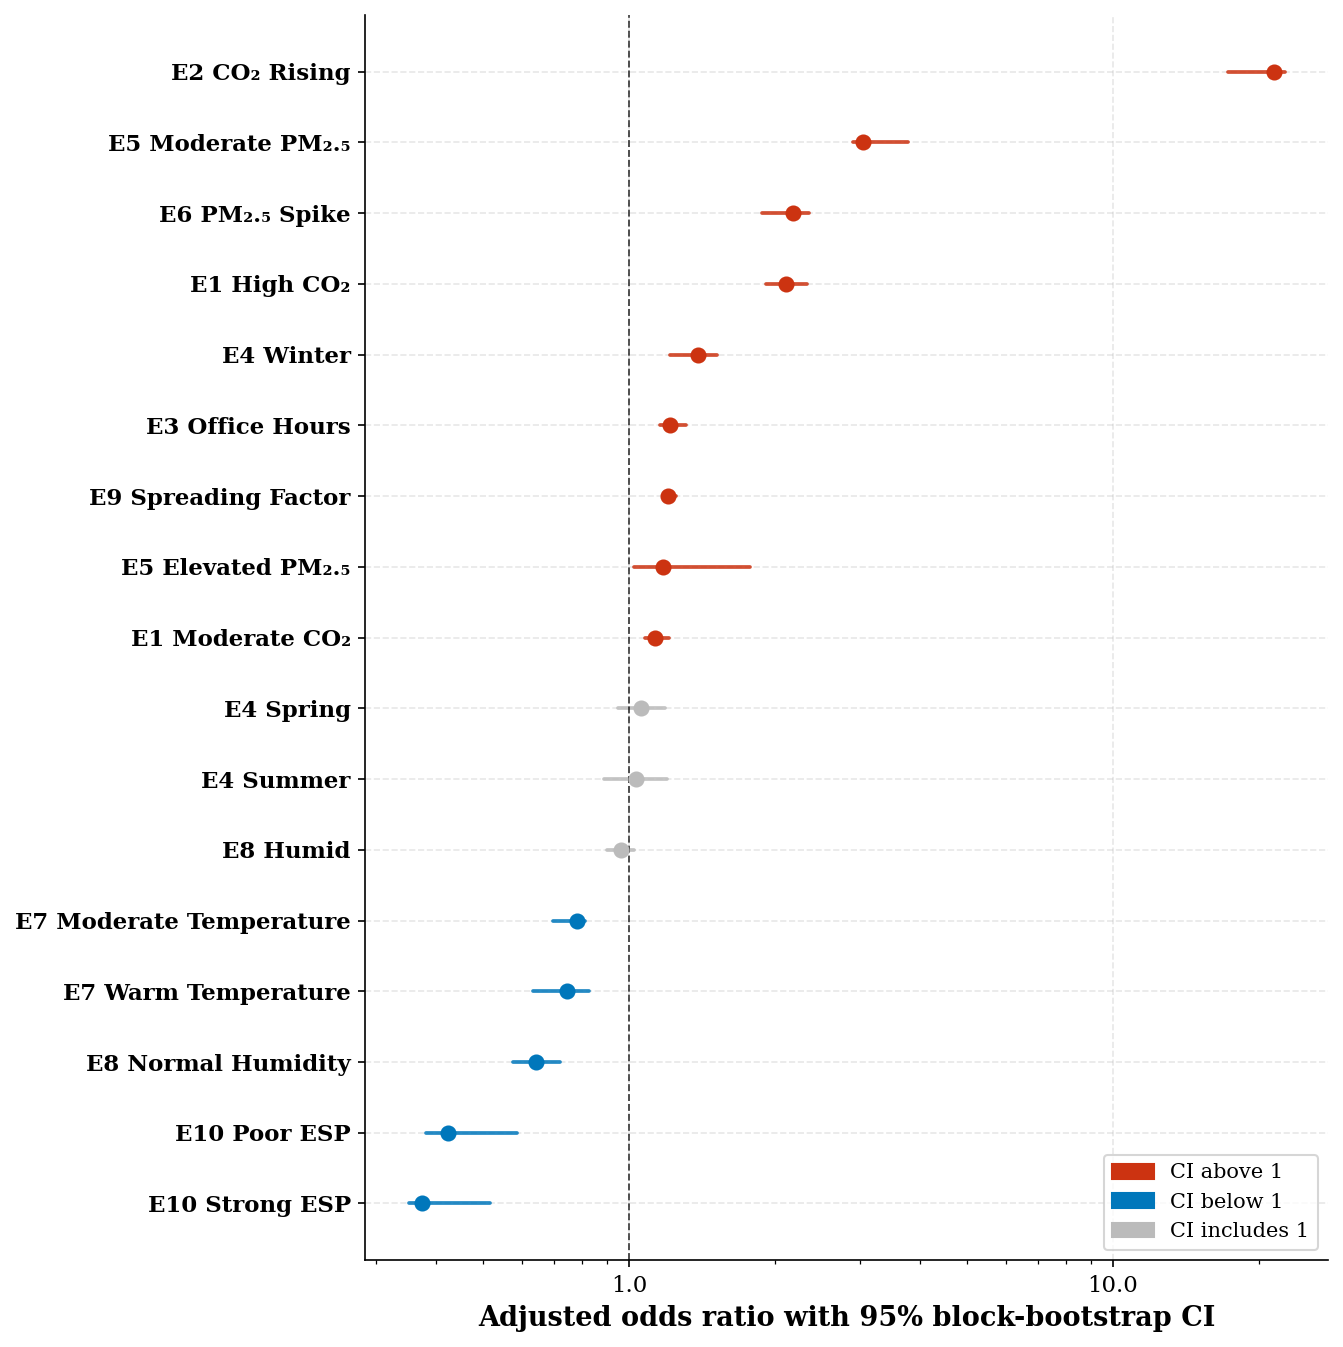

In [19]:
# Fig 03-I — Loss Occurrence Odds-Ratio Forest Plot

plot_labels = {
    'e1_co2_tier_high': 'E1 High CO₂',
    'e1_co2_tier_moderate': 'E1 Moderate CO₂',
    'e2_co2_rising': 'E2 CO₂ Rising',
    'e3_office_hours': 'E3 Office Hours',
    'e4_season_spring': 'E4 Spring',
    'e4_season_summer': 'E4 Summer',
    'e4_season_winter': 'E4 Winter',
    'e5_pm25_tier_elevated': 'E5 Elevated PM₂.₅',
    'e5_pm25_tier_moderate': 'E5 Moderate PM₂.₅',
    'e6_pm25_spike': 'E6 PM₂.₅ Spike',
    'e7_temp_tier_moderate': 'E7 Moderate Temperature',
    'e7_temp_tier_warm': 'E7 Warm Temperature',
    'e8_humidity_tier_humid': 'E8 Humid',
    'e8_humidity_tier_normal': 'E8 Normal Humidity',
    'e9_sf': 'E9 Spreading Factor',
    'e10_esp_tier_poor': 'E10 Poor ESP',
    'e10_esp_tier_strong': 'E10 Strong ESP',
}

event_index = [
    feat for feat in ci_loss.index
    if not feat.startswith('device_id')
]

ev_j = ci_loss.loc[
    event_index,
    ['OR', 'CI_lo', 'CI_hi', 'Supported'],
].copy()

ev_j['label'] = [
    plot_labels.get(feat, feat)
    for feat in ev_j.index
]

ev_j = (
    ev_j
    .sort_values('OR', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(10, len(ev_j) * 0.42 + 2)
)

for i, row in ev_j.iterrows():
    if row['CI_lo'] > 1.0:
        color = C['red']
    elif row['CI_hi'] < 1.0:
        color = C['blue']
    else:
        color = C['grey']

    ax.plot(
        [row['CI_lo'], row['CI_hi']],
        [i, i],
        color=color,
        lw=1.8,
        alpha=0.85,
        solid_capstyle='round',
    )

    ax.scatter(
        row['OR'],
        i,
        color=color,
        s=45,
        zorder=5,
    )

ax.axvline(
    x=1.0,
    color='black',
    lw=0.9,
    ls='--',
    alpha=0.7,
)

ax.set_yticks(range(len(ev_j)))

ax.set_yticklabels(
    ev_j['label'],
    fontsize=11,
    fontweight='bold',
)

ax.set_xlabel(
    'Adjusted odds ratio with 95% block-bootstrap CI',
    fontsize=13,
    fontweight='bold',
)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(
    mticker.ScalarFormatter()
)
ax.tick_params(
    axis='x',
    labelsize=11,
)

ax.legend(
    handles=[
        mpatches.Patch(
            color=C['red'],
            label='CI above 1',
        ),
        mpatches.Patch(
            color=C['blue'],
            label='CI below 1',
        ),
        mpatches.Patch(
            color=C['grey'],
            label='CI includes 1',
        ),
    ],
    loc='lower right',
    fontsize=10,
)

fig.tight_layout()
fig.subplots_adjust(left=0.34)

save_fig(
    fig,
    '03_i_loss_risk_forest',
)

plt.show()

## 11 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same framework predicting burst loss: `y = 1[tx_loss >= 3]`

Burst-loss ORs are systematically larger than packet-loss ORs for the same
events — high-occupancy and high-SF conditions disproportionately increase burst severity.


In [20]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST OCCURRENCE MODEL')
print('=' * 60)

df_link['burst_occurred'] = (
    df_link['tx_loss'] >= 3
).astype(int)

y_burst = df_link[
    'burst_occurred'
].to_numpy(dtype=int)

print(
    f'Fitting burst occurrence model with '
    f'{N_BOOT:,} one-day block resamples'
)

or_burst, ci_burst = fit_lr_block_bootstrap(
    X,
    y_burst,
    lr_block_id,
    feat_names,
)

print(
    f'\n{"Predictor":<40} '
    f'{"OR loss":>10} '
    f'{"95% CI loss":>22} '
    f'{"OR burst":>10} '
    f'{"95% CI burst":>22}'
)

print('-' * 110)

for feat in odds_ratios.index:
    if feat.startswith('device_id'):
        continue

    or_l = odds_ratios[feat]
    lo_l = ci_loss.loc[feat, 'CI_lo']
    hi_l = ci_loss.loc[feat, 'CI_hi']

    or_b = or_burst[feat]
    lo_b = ci_burst.loc[feat, 'CI_lo']
    hi_b = ci_burst.loc[feat, 'CI_hi']

    print(
        f'{feat:<40} '
        f'{or_l:>10.4f} '
        f'[{lo_l:.3f}, {hi_l:.3f}] '
        f'{or_b:>10.4f} '
        f'[{lo_b:.3f}, {hi_b:.3f}]'
    )

print(
    '\nDevice-location terms remain in both models '
    'as controls and are omitted from this comparison.'
)

print(
    'The two odds ratios describe different binary '
    'outcomes and are presented side by side without '
    'forming an odds-ratio ratio.'
)

LOGISTIC REGRESSION — BURST OCCURRENCE MODEL
Fitting burst occurrence model with 25 one-day block resamples
  Completed 25 of 25 block resamples

Predictor                                   OR loss            95% CI loss   OR burst           95% CI burst
--------------------------------------------------------------------------------------------------------------
e2_co2_rising                               21.4818 [17.281, 22.613]    15.5405 [5.900, 51.069]
e5_pm25_tier_moderate                        3.0520 [2.908, 3.778]     7.1803 [4.541, 11.586]
e6_pm25_spike                                2.1790 [1.885, 2.357]     2.8154 [1.894, 3.230]
e1_co2_tier_high                             2.1157 [1.920, 2.338]     3.0044 [1.926, 3.956]
e4_season_winter                             1.3865 [1.216, 1.519]     0.3421 [0.261, 0.877]
e3_office_hours                              1.2169 [1.158, 1.309]     1.3337 [1.051, 1.658]
e9_sf                                        1.2054 [1.195, 1.251]     0

Computing micro-granular burst size odds ratios (Sizes 0–9)...
  Saved: figures/3/03_j_loss_vs_detailed_burst_or


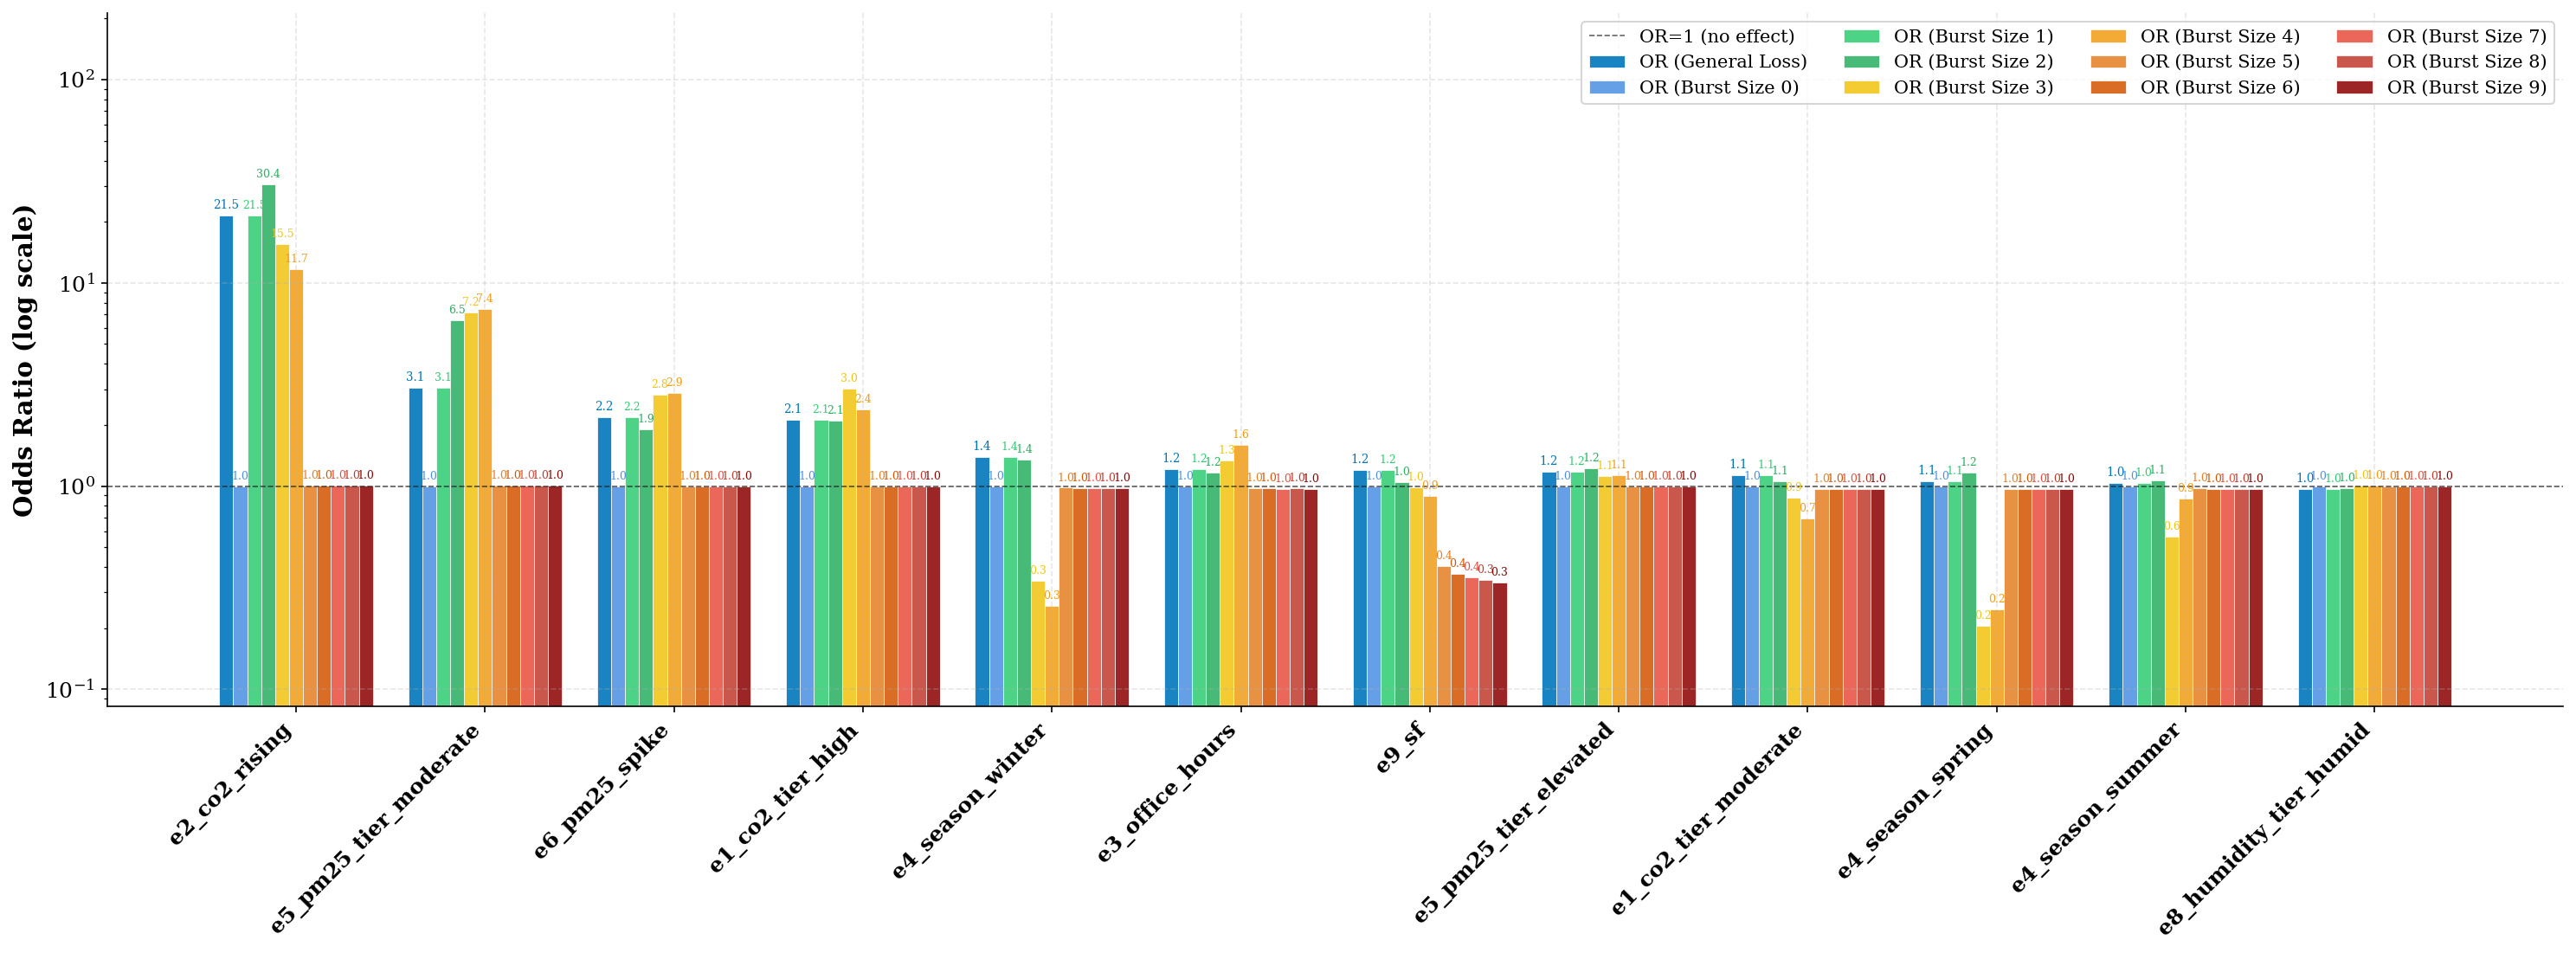

In [21]:
# Fig 03-J — Loss vs Detailed Burst Size OR comparison (top 12)
from sklearn.linear_model import LogisticRegression

print("Computing micro-granular burst size odds ratios (Sizes 0–9)...")
or_burst_sizes = {}
for size in range(10):
    if size == 0:
        # Size 0 represents perfect transmission / baseline reference condition
        or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
    else:
        # Fast single fit of logistic regression for cumulative burst severity: tx_loss >= size
        y_size = (df_link['tx_loss'] >= size).astype(int)
        if len(np.unique(y_size)) > 1:
            try:
                model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
                model.fit(X, y_size)
                ors = np.exp(model.coef_[0])
                or_burst_sizes[size] = dict(zip(feat_names, ors))
            except Exception:
                or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
        else:
            or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}

burst_sizes = list(range(10))  # 0 to 9 inclusive
ev_rows = []

for feat in feat_names:
    if feat.startswith('device_id'): continue

    row_dict = {
        'predictor': feat,
        'OR_loss': float(odds_ratios.get(feat, 1.0))
    }

    for size in burst_sizes:
        val = or_burst_sizes[size].get(feat, 1.0)
        row_dict[f'OR_burst_{size}'] = float(val)

    ev_rows.append(row_dict)

ev = pd.DataFrame(ev_rows)
ev_top = ev.sort_values('OR_loss', ascending=False).head(12).reset_index(drop=True)

x = np.arange(len(ev_top)) * 1.15
# 1 general loss bar + 10 individual burst size bars = 11 bars total per group
w = 0.085

fig, ax = plt.subplots(figsize=(20, 7.5))

# Plot General Loss baseline bar
ax.bar(x - 5 * w, ev_top['OR_loss'], w, color=C['blue'], alpha=0.9,
       label='OR (General Loss)', edgecolor='white', lw=0.4)

# 10 distinct colors matching your custom color environment context mapping from cool to hot
burst_colors = [
    '#4a90e2', '#2ecc71', '#27ae60', '#f1c40f', '#f39c12',
    '#e67e22', '#d35400', '#e74c3c', '#c0392b', '#8b0000'
]

for idx, size in enumerate(burst_sizes):
    ax.bar(x - (4 - idx) * w, ev_top[f'OR_burst_{size}'], w, color=burst_colors[idx],
           alpha=0.85, label=f'OR (Burst Size {size})', edgecolor='white', lw=0.4)

ax.axhline(y=1.0, color='black', lw=0.8, ls='--', alpha=0.6, label='OR=1 (no effect)')
ax.set_yscale('log')

# Micro-text layout for ultra-packed data columns
for i2, row in ev_top.iterrows():
    xi = x[i2]
    ax.text(xi - 5 * w, row['OR_loss'] * 1.05, f'{row["OR_loss"]:.1f}', ha='center', va='bottom', fontsize=6.5,
            color=C['blue'])
    for idx, size in enumerate(burst_sizes):
        val = row[f'OR_burst_{size}']
        ax.text(xi - (4 - idx) * w, val * 1.05, f'{val:.1f}', ha='center', va='bottom', fontsize=6,
                color=burst_colors[idx])

ax.set_xticks(x)
ax.set_xticklabels(ev_top['predictor'], rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_ylabel('Odds Ratio (log scale)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('Loss Risk vs Micro-Granular Burst Size Odds Ratios (Sizes 0–9) — Top 12 Predictors', fontsize=12, fontweight='bold')

# Compact matrix legend layout to keep it clean
ax.legend(fontsize=10, loc='upper right', ncol=4)

all_or_cols = ['OR_loss'] + [f'OR_burst_{s}' for s in burst_sizes]
ax.set_ylim(bottom=min(ev_top[all_or_cols].min()) * 0.4, top=max(ev_top[all_or_cols].max()) * 7)

fig.tight_layout()
save_fig(fig, '03_j_loss_vs_detailed_burst_or')

## 12 · Key Findings Summary  *(§7 summary)*

Thesis-ready statements for Chapter 7.


In [22]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

# Campaign-wide reliability metrics
lost_link = int(df_link['tx_loss'].sum())

pdr_link = (
    len(df_link)
    / (len(df_link) + lost_link)
    * 100
)

total_app = int(df['fw_drop'].sum())
total_radio = int(df['tx_loss'].sum())

pdr_system = (
    len(df)
    / (len(df) + total_app + total_radio)
    * 100
)

pdr_raw = (
    len(df)
    / (len(df) + total_radio)
    * 100
)

# Per-device link-layer PDR spread
device_pdrs = df_link.groupby(
    'device_id',
    observed=True,
).apply(
    lambda g: (
        len(g)
        / (
            len(g)
            + int(g['tx_loss'].sum())
        )
        * 100
    ),
    include_groups=False,
)

pdr_range = float(
    device_pdrs.max()
    - device_pdrs.min()
)

print(f"""
┌─ RQ1  Campaign-Wide Reliability ───────────────────────────┐
  PDR_system                  {pdr_system:>10.2f}%
  PDR_raw                     {pdr_raw:>10.2f}%
  PDR_link                    {pdr_link:>10.2f}%
  PDR range across devices    {pdr_range:>10.2f} pp
  Intervals analysed          {len(df_link):>10,}
└────────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2  Event-Conditioned PDR ───────────────────────────────────────────────────┐
  Top findings ranked by absolute PDR difference

  {'Event':<8} {'Comparison':<38} {'Diff pp':>10} {'95% CI pp':>22} {'Supported':>12}
  {'-' * 94}""")

top_n = results_df.reindex(
    results_df['Diff_pp']
    .abs()
    .sort_values(
        ascending=False
    )
    .index
).head(6)

for _, row in top_n.iterrows():
    ci = (
        f"[{row['CI_low_pp']:+.2f}, "
        f"{row['CI_high_pp']:+.2f}]"
    )

    supported = (
        'Yes'
        if row['Supported']
        else 'No'
    )

    print(
        f"  {row['Event']:<8} "
        f"{row['Comparison']:<38} "
        f"{row['Diff_pp']:>+9.2f} "
        f"{ci:>22} "
        f"{supported:>12}"
    )

# Retain only predictors present in both fitted models
event_predictors = [
    feat
    for feat in odds_ratios.index
    if (
        not feat.startswith('device_id')
        and feat in or_burst.index
    )
]

# Rank predictors by their strongest distance from OR = 1
top_predictors = sorted(
    event_predictors,
    key=lambda feat: max(
        abs(np.log(odds_ratios[feat])),
        abs(np.log(or_burst[feat])),
    ),
    reverse=True,
)[:5]

print(f"""
┌─ RQ3  Strongest Adjusted Associations ─────────────────────────────────────────────────────────────┐

  {'Predictor':<38} {'OR loss':>10} {'95% CI loss':>22} {'OR burst':>10} {'95% CI burst':>22}
  {'-' * 106}""")

for feat in top_predictors:
    or_l = odds_ratios[feat]
    lo_l = ci_loss.loc[
        feat,
        'CI_lo',
    ]
    hi_l = ci_loss.loc[
        feat,
        'CI_hi',
    ]

    or_b = or_burst[feat]
    lo_b = ci_burst.loc[
        feat,
        'CI_lo',
    ]
    hi_b = ci_burst.loc[
        feat,
        'CI_hi',
    ]

    print(
        f'  {feat:<38} '
        f'{or_l:>10.3f} '
        f'[{lo_l:.3f}, {hi_l:.3f}] '
        f'{or_b:>10.3f} '
        f'[{lo_b:.3f}, {hi_b:.3f}]'
    )

print("""
  Device-location indicators were included as adjustment variables
  and are omitted from this summary.
└─────────────────────────────────────────────────────────────────────────────────────────────────────┘
""")

KEY FINDINGS SUMMARY

┌─ RQ1  Campaign-Wide Reliability ───────────────────────────┐
  PDR_system                       83.77%
  PDR_raw                          91.04%
  PDR_link                         97.83%
  PDR range across devices          1.81 pp
  Intervals analysed           2,634,454
└────────────────────────────────────────────────────────────┘


┌─ RQ2  Event-Conditioned PDR ───────────────────────────────────────────────────┐
  Top findings ranked by absolute PDR difference

  Event    Comparison                                Diff pp              95% CI pp    Supported
  ----------------------------------------------------------------------------------------------
  E2       CO2 rising vs stable                      -31.77       [-36.22, -27.00]          Yes
  E5       Elevated vs Clean PM2.5                   -21.57       [-36.52, -15.45]          Yes
  E6       PM2.5 spike vs normal                      -3.29         [-4.36, -2.19]          Yes
  E1       High CO2 vs B

## 13 · Save Results


In [23]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame({
    'predictor': odds_ratios.index,
    'OR_loss': odds_ratios.values,
    'loss_CI_lo': [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'loss_CI_hi': [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
    'OR_burst': [or_burst[f] for f in odds_ratios.index],
    'burst_CI_lo': [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'burst_CI_hi': [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
})
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
print(f'\nNotebook 03 complete.')


Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv

Notebook 03 complete.
